In [1]:
# ============================================================================
# Environment
#   R >= 4.4 with the IRkernel ("ir") Jupyter kernel.
#   Run this notebook from the directory that contains it -- the one holding
#   survey_data/ -- so the relative ./survey_data/ paths below resolve.
#   Every package used anywhere in this notebook is listed here; missing ones
#   are installed on first run.
# ============================================================================

# Only what the notebook actually calls. Packages that are merely
# dependencies (Matrix, TMB, nlme via glmmTMB) load on their own; attaching
# them explicitly added startup banners and install weight for no benefit.
need <- c("readxl", "dplyr", "forcats", "purrr", "tibble", "scales",
          "ggplot2", "ggh4x", "systemfonts", "ragg",
          "mgcv", "glmmTMB", "fixest")

to_install <- setdiff(need, rownames(installed.packages()))
if (length(to_install)) install.packages(to_install, repos = "https://cloud.r-project.org")

cat("R version:", R.version.string, "\n")
print(sessionInfo()$platform)


library(readxl)
library(dplyr)
library(forcats)
library(ggplot2)
library(glmmTMB)
library(purrr)
library(tibble)
library(fixest)

set.seed(42)
# ================================
# 1) Data & Preprocessing
# ================================
# Generated figures are written here, not to the notebook's directory.
FIG_DIR <- "figures"
dir.create(FIG_DIR, showWarnings = FALSE, recursive = TRUE)

df <- read_excel("./survey_data/survey_results/survey_results.xlsx")

df <- df %>%
  mutate(
    Nationality = as.factor(Nationality),
    Sex         = as.factor(Sex),
    Language    = as.factor(Language),
    Age         = as.numeric(Age),
    
    c    = as.numeric(c),
    c_2  = as.numeric(c_2),
    
    controversy = as.integer(controversy),
    certainty   = as.integer(certainty),
    both        = as.integer(both),
    control     = as.integer(control),
    
    disagree = ifelse(is.na(disagree), 0, as.numeric(disagree)) / 100,
    inconf   = ifelse(is.na(inconf),   0, as.numeric(inconf))   / 100,
    outconf  = ifelse(is.na(outconf),  0, as.numeric(outconf))  / 100,
    
    delta_c = c_2 - c
  )

# ================================
# 2) New Variables (ported from Python)
# ================================
df <- df %>%
  mutate(
    # Disagreement rate: share of others who hold the opposite judgment
    disagreement_rate = ifelse(j == "NA", post_YA_Percentage, post_NA_Percentage),
    certainty_diff     = inconf - outconf,
    in_minority          = as.integer(disagreement_rate >= 50),
    ingroup_more_certain = as.integer(certainty_diff >= 0)
  )

# ================================
# 3) Remaining preprocessing
# ================================
df <- df %>%
  mutate(
    destablized = (j != j_2) | (j == j_2 & c_2 < c)
  )

R version: R version 4.4.1 (2024-06-14) 
[1] "x86_64-apple-darwin20"



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”


In [2]:
table(df$destablized, useNA = "ifany")


FALSE  TRUE 
 3844   474 

## Global data recoding & grouping

All Sex grouping, Country/Nationality recoding, `Nationality_grouped`, `destablized_int`, and `df_clean` are built here once and shared across all model cells.

In [3]:
# ================================
# Global: Recode Sex
#    Female, Male, Other
#    (absorbs CONSENT_REVOKED,
#     DATA_EXPIRED, Prefer not to say)
#    Also cast post_id to factor once.
# ================================

df <- df %>%
  mutate(
    Sex_grouped = case_when(
      Sex == "Female" ~ "Female",
      Sex == "Male"   ~ "Male",
      TRUE            ~ "Other"
    ),
    Sex_grouped = as.factor(Sex_grouped),
    Sex_grouped = relevel(Sex_grouped, ref = "Female"),
    post_id     = as.factor(post_id)
  )

df %>% count(Sex_grouped) %>% mutate(pct = round(n / sum(n) * 100, 2))

# ================================
# Global: Recode Country of residence
#    Tier A: n > 100 (50+ participants)
#    Tier B: n > 35  (17+ participants)
#    United States as reference in both
# ================================

country_counts <- df %>% count(`Country of residence`)

keep_country_A <- country_counts %>%
  filter(n > 100) %>%
  pull(`Country of residence`) %>%
  as.character()


cat("Country of residence Tier A (n > 100):\n")
print(keep_country_A)

df <- df %>%
  mutate(
    Country_A = fct_other(
      as.factor(`Country of residence`),
      keep        = keep_country_A,
      other_level = "Other"
    ),
    Country_A = relevel(Country_A, ref = "United States"),

    raw_country = as.factor(`Country of residence`),
    raw_country = relevel(raw_country, ref = "United States")
  )

cat("\nCountry_A distribution:\n")
df %>% count(Country_A) %>%
  mutate(participants = n / 2,
         pct = round(participants / sum(participants) * 100, 1)) %>%
  arrange(desc(participants)) %>% print()


# ================================
# Global: Recode Nationality
#    Same two thresholds applied to
#    Nationality column separately
#    United States as reference in both
# ================================

nationality_counts <- df %>% count(Nationality)

keep_nat_A <- nationality_counts %>%
  filter(n > 100) %>%
  pull(Nationality) %>%
  as.character()


cat("\nNationality Tier A (n > 100):\n")
print(keep_nat_A)


df <- df %>%
  mutate(
    Nationality_A = fct_other(
      as.factor(Nationality),
      keep        = keep_nat_A,
      other_level = "Other"
    ),
    Nationality_A = relevel(Nationality_A, ref = "United States"),


    raw_nationality = as.factor(Nationality),
    raw_nationality = relevel(raw_nationality, ref = "United States")
  )

cat("\nNationality_A distribution:\n")
df %>% count(Nationality_A) %>%
  mutate(participants = n / 2,
         pct = round(participants / sum(participants) * 100, 1)) %>%
  arrange(desc(participants)) %>% print()



# ================================
# Global: Nationality_grouped
#    Five-country grouping used in
#    glmmTMB cells
# ================================

keep_countries <- c("United States", "South Africa",
                    "United Kingdom", "Canada", "Australia")

df <- df %>%
  mutate(
    Nationality_grouped = fct_other(
      as.factor(Nationality),
      keep        = keep_countries,
      other_level = "Other"
    )
  )

df %>% count(Nationality_grouped) %>% mutate(pct = round(n / sum(n) * 100, 1))

# ================================
# Global: destablized_int
#    Clean 0/1 integer outcome
# ================================

df <- df %>%
  mutate(destablized_int = as.integer(destablized))

cat("destablized_int distribution:\n")
print(table(df$destablized_int, useNA = "always"))

print(df %>% 
  count(Nationality) %>% 
  mutate(pct = round(n / sum(n) * 100, 1)) %>% 
  print(n = Inf))

print(df %>% 
  count(`Country of residence`) %>% 
  mutate(pct = round(n / sum(n) * 100, 1)) %>% 
  print(n = Inf))



Sex_grouped,n,pct
<fct>,<int>,<dbl>
Female,2138,49.51
Male,2176,50.39
Other,4,0.09


Country of residence Tier A (n > 100):
[1] "Australia"      "Canada"         "South Africa"   "United Kingdom"
[5] "United States" 

Country_A distribution:
# A tibble: 6 × 4
  Country_A          n participants   pct
  <fct>          <int>        <dbl> <dbl>
1 United States   1688          844  39.1
2 South Africa    1018          509  23.6
3 Other            558          279  12.9
4 United Kingdom   512          256  11.9
5 Canada           298          149   6.9
6 Australia        244          122   5.7

Nationality Tier A (n > 100):
[1] "Australia"      "Canada"         "South Africa"   "United Kingdom"
[5] "United States" 

Nationality_A distribution:
# A tibble: 6 × 4
  Nationality_A      n participants   pct
  <fct>          <int>        <dbl> <dbl>
1 United States   1616          808  37.4
2 South Africa     990          495  22.9
3 Other            798          399  18.5
4 United Kingdom   440          220  10.2
5 Canada           264          132   6.1
6 Australia        210  

Nationality_grouped,n,pct
<fct>,<int>,<dbl>
Australia,210,4.9
Canada,264,6.1
South Africa,990,22.9
United Kingdom,440,10.2
United States,1616,37.4
Other,798,18.5


destablized_int distribution:

   0    1 <NA> 
3844  474    0 
# A tibble: 65 × 3
   Nationality                              n   pct
   <fct>                                <int> <dbl>
 1 American Samoa                           2   0  
 2 Argentina                                4   0.1
 3 Australia                              210   4.9
 4 Austria                                  6   0.1
 5 Bangladesh                               2   0  
 6 Belgium                                  4   0.1
 7 Bosnia and Herzegovina                   2   0  
 8 Brazil                                  20   0.5
 9 Canada                                 264   6.1
10 Chile                                   18   0.4
11 China                                   16   0.4
12 Czech Republic                          10   0.2
13 DATA_EXPIRED                            10   0.2
14 Denmark                                  6   0.1
15 Egypt                                    2   0  
16 Estonia                        

In [4]:
# =============================================================================
# POMP rescaling of Likert covariates to [0, 1]
# Formula: pomp(x) = (x - theoretical_min) / (theoretical_max - theoretical_min)
# Theoretical anchors (NOT observed sample min/max) are used so the metric is
# sample-independent and interpretable as "fraction of the scale used."
# =============================================================================

# ---- Helper -----------------------------------------------------------------
pomp <- function(x, scale_min, scale_max) {
  (x - scale_min) / (scale_max - scale_min)
}

# ---- Initial Confidence: 4-point Likert (single item) -----------------------
df$c <- pomp(df$c, scale_min = 1, scale_max = 4)
df$c_2 <- pomp(df$c_2, scale_min = 1, scale_max = 4)

# ---- Big Five Personality: 7-point Likert (composite means) -----------------
big_five <- c("Openness", "Conscientiousness", "Extraversion",
              "Agreeableness", "EmotionalStability")
df[big_five] <- lapply(df[big_five], pomp, scale_min = 1, scale_max = 7)

# ---- GDMS Decision-Making Styles: 5-point Likert (composite means) ----------
gdms <- c("Intuitive", "Dependent", "Rational", "Avoidant", "Spontaneous")
df[gdms] <- lapply(df[gdms], pomp, scale_min = 1, scale_max = 5)

# ---- Intellectual Humility: 5-point Likert (composite mean) -----------------
df$IH <- pomp(df$IH, scale_min = 1, scale_max = 5)

# ---- Sanity check: every rescaled covariate should fall in [0, 1] -----------
rescaled_vars <- c("c", big_five, gdms, "IH")
summary(df[rescaled_vars])
stopifnot(all(sapply(df[rescaled_vars],
                     function(v) all(v >= 0 & v <= 1, na.rm = TRUE))))

       c             Openness      Conscientiousness  Extraversion   
 Min.   :0.0000   Min.   :0.0000   Min.   :0.0000    Min.   :0.0000  
 1st Qu.:0.6667   1st Qu.:0.5833   1st Qu.:0.5833    1st Qu.:0.1667  
 Median :1.0000   Median :0.7500   Median :0.8333    Median :0.4167  
 Mean   :0.8114   Mean   :0.7137   Mean   :0.7607    Mean   :0.4106  
 3rd Qu.:1.0000   3rd Qu.:0.9167   3rd Qu.:0.9167    3rd Qu.:0.5833  
 Max.   :1.0000   Max.   :1.0000   Max.   :1.0000    Max.   :1.0000  
 Agreeableness    EmotionalStability   Intuitive        Dependent     
 Min.   :0.0000   Min.   :0.0000     Min.   :0.0000   Min.   :0.0000  
 1st Qu.:0.5833   1st Qu.:0.5000     1st Qu.:0.5000   1st Qu.:0.2500  
 Median :0.7500   Median :0.6667     Median :0.6667   Median :0.4167  
 Mean   :0.7090   Mean   :0.6584     Mean   :0.6182   Mean   :0.4088  
 3rd Qu.:0.8333   3rd Qu.:0.8333     3rd Qu.:0.7500   3rd Qu.:0.5833  
 Max.   :1.0000   Max.   :1.0000     Max.   :1.0000   Max.   :1.0000  
    Rational 

# Model ablation for weakening

## glm

In [5]:
library(purrr)
library(tibble)
library(dplyr)
library(ggplot2)

# ================================
# 4) Two base formula strings
# ================================

base_no_post <- "destablized ~
    1 + c +
    controversy + controversy:(disagree) +
    certainty   + certainty:(inconf + outconf) +
    both        + both:(disagree + inconf + outconf)"

base_with_post <- "destablized ~
    1 + c +
    controversy + controversy:(disagree) +
    certainty   + certainty:(inconf + outconf) +
    both        + both:(disagree + inconf + outconf) +
    post_id"

# ================================
# 5) Block definitions
# ================================

blocks_single <- list(
  "base"                  = NULL,
  "+ Topic"               = c("post_topic_1", "post_topic_2"),
  "+ Personality"         = c("Openness", "Conscientiousness", "Extraversion",
                               "Agreeableness", "EmotionalStability"),
  "+ GDMS"                = c("Intuitive", "Dependent", "Rational",
                               "Avoidant", "Spontaneous"),
  "+ IH"                  = "IH",
  "+ Age"                 = "scale(Age)",
  "+ Sex"                 = "Sex_grouped",
  "+ Country (A>100)"     = "Country_A",
  "+ Country (raw)"       = "raw_country",
  "+ Nationality (A>100)" = "Nationality_A",
  "+ Nationality (raw)"   = "raw_nationality"
)

block_lookup <- blocks_single[names(blocks_single) != "base"]

# ================================
# 6) Formula builder
# ================================

build_formulas_glm <- function(base_str, extras) {
  clean_str <- gsub("\\s+", " ", base_str)
  map(extras, function(cov) {
    if (is.null(cov)) as.formula(clean_str)
    else as.formula(paste(clean_str, "+", paste(cov, collapse = " + ")))
  })
}

formulas_single_no_post   <- build_formulas_glm(base_no_post,   blocks_single)
formulas_single_with_post <- build_formulas_glm(base_with_post, blocks_single)

# ================================
# 7) 10-fold CV
# ================================

set.seed(42)
n     <- nrow(df)
folds <- sample(rep(1:10, length.out = n))

cv_mean_loglik_glm <- function(formula, data, folds, k = 10) {
  fold_scores <- map_dbl(1:k, function(fold) {
    train_df <- data[folds != fold, ]
    val_df   <- data[folds == fold, ]
    fit <- tryCatch(glm(formula, data = train_df, family = binomial()),
                    error = function(e) NULL)
    if (is.null(fit)) return(NA_real_)
    p_hat <- tryCatch(suppressWarnings(
      predict(fit, newdata = val_df, type = "response")),
      error = function(e) rep(NA_real_, nrow(val_df)))
    y    <- as.integer(val_df$destablized)
    keep <- !is.na(p_hat)
    p_hat <- p_hat[keep]; y <- y[keep]
    if (length(y) == 0) return(NA_real_)
    p_hat <- pmax(pmin(p_hat, 1 - 1e-10), 1e-10)
    mean(y * log(p_hat) + (1 - y) * log(1 - p_hat))
  })
  list(fold_scores = fold_scores,
       mean_loglik = mean(fold_scores, na.rm = TRUE),
       se_loglik   = sd(fold_scores,   na.rm = TRUE) / sqrt(sum(!is.na(fold_scores))))
}

run_cv_table_glm <- function(formulas, data, folds) {
  results <- imap(formulas, function(formula, model_name) {
    cat("  Fitting:", model_name, "\n")
    cv_out <- cv_mean_loglik_glm(formula, data, folds)
    tibble(model = model_name, mean_loglik = cv_out$mean_loglik,
           se_loglik = cv_out$se_loglik, fold_scores = list(cv_out$fold_scores))
  })
  tbl <- bind_rows(results)
  base_ll <- tbl$mean_loglik[tbl$model == "base"]
  tbl %>% mutate(delta_loglik = mean_loglik - base_ll, rank = rank(-mean_loglik))
}

# ================================
# 8) Step 1 — Single-block ablation
# ================================

cat("--- Step 1: glm WITHOUT post_id ---\n")
table_single_no_post <- run_cv_table_glm(formulas_single_no_post, df, folds)
print(table_single_no_post %>% select(model, mean_loglik, se_loglik, delta_loglik, rank))

cat("--- Step 1: glm WITH post_id ---\n")
table_single_with_post <- run_cv_table_glm(formulas_single_with_post, df, folds)
print(table_single_with_post %>% select(model, mean_loglik, se_loglik, delta_loglik, rank))

# ================================
# 9) Step 2 — Nationality/Country filter
# ================================

country_blocks <- c("+ Country (A>100)", 
                    "+ Nationality (A>100)")
raw_blocks     <- c("+ Country (raw)", 
    "+ Nationality (raw)")

build_greedy_lookup <- function(table_single, label) {
  best_cb    <- table_single %>% filter(model %in% country_blocks) %>%
    arrange(desc(delta_loglik)) %>% slice(1) %>% pull(model)
  losing_cb  <- setdiff(country_blocks, best_cb)
  cat("\nStep 2 — Country/Nationality comparison (", label, "):\n", sep = "")
  table_single %>% filter(model %in% country_blocks) %>%
    select(model, delta_loglik) %>% arrange(desc(delta_loglik)) %>% print()
  cat("  Winner:", best_cb, "\n")
  block_lookup[!names(block_lookup) %in% c(losing_cb, raw_blocks)]
}

greedy_lookup_no_post   <- build_greedy_lookup(table_single_no_post,   "no post_id")
greedy_lookup_with_post <- build_greedy_lookup(table_single_with_post, "with post_id")

# ================================
# 10) Step 3 — Greedy forward selection
# ================================

greedy_forward_cv_glm <- function(base_str, lookup, data, folds) {
  remaining    <- names(lookup)
  current_covs <- character(0)
  clean_str    <- gsub("\\s+", " ", base_str)

  build_formula <- function(covs) {
    if (length(covs) == 0) as.formula(clean_str)
    else as.formula(paste(clean_str, "+", paste(covs, collapse = " + ")))
  }

  base_cv    <- cv_mean_loglik_glm(build_formula(character(0)), data, folds)
  current_ll <- base_cv$mean_loglik

  rows <- list(tibble(
    step = 0L, added = "base",
    mean_loglik = base_cv$mean_loglik, se_loglik = base_cv$se_loglik,
    delta_loglik = 0, improved = TRUE
  ))

  step <- 1L

  while (length(remaining) > 0) {
    cat("  Step", step, "| remaining:", paste(remaining, collapse = ", "), "\n")

    cands <- map_dfr(remaining, function(blk) {
      covs   <- c(current_covs, lookup[[blk]])
      cv_out <- cv_mean_loglik_glm(build_formula(covs), data, folds)
      tibble(block = blk, mean_loglik = cv_out$mean_loglik,
             se_loglik = cv_out$se_loglik, delta = cv_out$mean_loglik - current_ll)
    })

    best <- cands %>% filter(delta > 0) %>% arrange(desc(delta)) %>% slice(1)

    if (nrow(best) > 0) {
      blk          <- best$block
      current_covs <- c(current_covs, lookup[[blk]])
      remaining    <- setdiff(remaining, blk)
      current_ll   <- best$mean_loglik
      rows[[step + 1]] <- tibble(
        step = step, added = blk,
        mean_loglik = best$mean_loglik, se_loglik = best$se_loglik,
        delta_loglik = best$delta, improved = TRUE
      )
    } else {
      cat("  No single block improved at step", step, "— recording remaining and stopping.\n")
      # Nat/country blocks are substituted (not added) to avoid including two at once.
      # All other remaining blocks are recorded from the already-computed cands.
      nat_covs <- c("Country_A",  "Nationality_A", 
                    "raw_country", "raw_nationality")
      for (blk in remaining) {
        blk_covs   <- lookup[[blk]]
        is_nat_blk <- any(blk_covs %in% nat_covs)
        if (is_nat_blk) {
          base_covs <- current_covs[!current_covs %in% nat_covs]
          test_covs <- c(base_covs, blk_covs)
          cv_out    <- cv_mean_loglik_glm(build_formula(test_covs), data, folds)
          blk_ll    <- cv_out$mean_loglik
          blk_se    <- cv_out$se_loglik
          blk_delta <- cv_out$mean_loglik - current_ll
          blk_label <- paste0("substitute(", blk, ")")
        } else {
          blk_row   <- cands %>% filter(block == blk)
          blk_ll    <- blk_row$mean_loglik
          blk_se    <- blk_row$se_loglik
          blk_delta <- blk_row$delta
          blk_label <- blk
        }
        rows[[length(rows) + 1]] <- tibble(
          step         = step,
          added        = blk_label,
          mean_loglik  = blk_ll,
          se_loglik    = blk_se,
          delta_loglik = blk_delta,
          improved     = FALSE
        )
        step <- step + 1L
      }
      remaining <- character(0)
    }

    step <- step + 1L
  }

  bind_rows(rows)
}

cat("--- Step 3: Greedy forward selection — glm WITHOUT post_id ---\n")
table_greedy_no_post <- greedy_forward_cv_glm(base_no_post, greedy_lookup_no_post, df, folds)
print(table_greedy_no_post %>% select(step, added, mean_loglik, se_loglik, delta_loglik, improved))

cat("--- Step 3: Greedy forward selection — glm WITH post_id ---\n")
table_greedy_with_post <- greedy_forward_cv_glm(base_with_post, greedy_lookup_with_post, df, folds)
print(table_greedy_with_post %>% select(step, added, mean_loglik, se_loglik, delta_loglik, improved))

# ================================
# 11) Step 4 — Best model summary and full-data fit
# ================================

summarize_and_fit_glm <- function(table_greedy, lookup, base_str, label, data) {
  best_row    <- table_greedy %>% filter(mean_loglik == max(mean_loglik)) %>% slice(1)
  steps_taken <- table_greedy %>%
    filter(step <= best_row$step, step > 0) %>%
    pull(added)
  all_added <- steps_taken
  best_covs <- unlist(lookup[all_added], use.names = FALSE)
  clean_str <- gsub("\\s+", " ", base_str)
  best_formula <- if (length(best_covs) > 0) {
    as.formula(paste(clean_str, "+", paste(best_covs, collapse = " + ")))
  } else {
    as.formula(clean_str)
  }
  cat("\n========================================\n")
  cat("Best model:", label, "\n")
  cat("========================================\n")
  cat("Step reached        :", best_row$step, "\n")
  cat("Blocks added        :", paste(steps_taken, collapse = " -> "), "\n")
  cat("Covariates included :", paste(best_covs, collapse = ", "), "\n")
  cat("Mean log-likelihood :", round(best_row$mean_loglik, 6), "\n")
  cat("SE                  :", round(best_row$se_loglik,   6), "\n")
  cat("Delta vs base       :", round(best_row$delta_loglik, 6), "\n")
  cat("========================================\n")
  # Full-data fit not printed here: only the selected model is summarised,
  # in the "Best model selection" cell below.
  fit <- glm(best_formula, data = data, family = binomial())
  invisible(fit)
}
fit_glm_no_post   <- summarize_and_fit_glm(table_greedy_no_post,   greedy_lookup_no_post,   base_no_post,   "glm WITHOUT post_id", df)
fit_glm_with_post <- summarize_and_fit_glm(table_greedy_with_post, greedy_lookup_with_post, base_with_post, "glm WITH post_id",    df)

# ================================
# 13) Snapshot glm's best-of-{no_post, with_post} result for
#     cross-family comparison (see "Best model selection" below).
# ================================

weak_glm_variants <- tibble(
  variant     = c("no_post_id", "with_post_id"),
  mean_loglik = c(max(table_greedy_no_post$mean_loglik),
                  max(table_greedy_with_post$mean_loglik))
)
weak_glm_best_variant <- weak_glm_variants$variant[which.max(weak_glm_variants$mean_loglik)]

if (weak_glm_best_variant == "no_post_id") {
  weak_glm_best_row  <- table_greedy_no_post %>% filter(mean_loglik == max(mean_loglik)) %>% slice(1)
  weak_glm_best_covs <- unlist(greedy_lookup_no_post[
    table_greedy_no_post %>% filter(step <= weak_glm_best_row$step, step > 0) %>% pull(added)
  ], use.names = FALSE)
  weak_glm_base_str  <- base_no_post
} else {
  weak_glm_best_row  <- table_greedy_with_post %>% filter(mean_loglik == max(mean_loglik)) %>% slice(1)
  weak_glm_best_covs <- unlist(greedy_lookup_with_post[
    table_greedy_with_post %>% filter(step <= weak_glm_best_row$step, step > 0) %>% pull(added)
  ], use.names = FALSE)
  weak_glm_base_str  <- base_with_post
}

weak_glm_result <- list(
  family      = "glm",
  variant     = weak_glm_best_variant,
  base_str    = weak_glm_base_str,
  fixed       = weak_glm_best_covs,
  random      = character(0),
  mean_loglik = weak_glm_best_row$mean_loglik,
  se_loglik   = weak_glm_best_row$se_loglik
)
cat("\n[Snapshot] glm weakening best (", weak_glm_best_variant, "): mean_loglik =",
    round(weak_glm_result$mean_loglik, 6), "\n")


--- Step 1: glm WITHOUT post_id ---
  Fitting: base 
  Fitting: + Topic 
  Fitting: + Personality 
  Fitting: + GDMS 
  Fitting: + IH 
  Fitting: + Age 
  Fitting: + Sex 
  Fitting: + Country (A>100) 
  Fitting: + Country (raw) 
  Fitting: + Nationality (A>100) 
  Fitting: + Nationality (raw) 
# A tibble: 11 × 5
   model                 mean_loglik se_loglik delta_loglik  rank
   <chr>                       <dbl>     <dbl>        <dbl> <dbl>
 1 base                       -0.315   0.00749    0             8
 2 + Topic                    -0.325   0.00839   -0.0106        9
 3 + Personality              -0.315   0.00744    0.0000884     7
 4 + GDMS                     -0.308   0.00814    0.00723       1
 5 + IH                       -0.314   0.00790    0.000963      2
 6 + Age                      -0.314   0.00816    0.000928      3
 7 + Sex                      -0.315   0.00768    0.000179      6
 8 + Country (A>100)          -0.314   0.00769    0.000709      5
 9 + Country (raw)        

Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


  Fitting: + Nationality (A>100) 
  Fitting: + Nationality (raw) 


Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


# A tibble: 11 × 5
   model                 mean_loglik se_loglik delta_loglik  rank
   <chr>                       <dbl>     <dbl>        <dbl> <dbl>
 1 base                       -0.396    0.0286    0           8.5
 2 + Topic                    -0.396    0.0286    0           8.5
 3 + Personality              -0.396    0.0281    0.000160    6  
 4 + GDMS                     -0.389    0.0289    0.00687     1  
 5 + IH                       -0.395    0.0287    0.000865    4  
 6 + Age                      -0.395    0.0288    0.00108     3  
 7 + Sex                      -0.396    0.0288    0.0000123   7  
 8 + Country (A>100)          -0.395    0.0290    0.000830    5  
 9 + Country (raw)            -0.437    0.0324   -0.0404     10  
10 + Nationality (A>100)      -0.395    0.0293    0.00115     2  
11 + Nationality (raw)        -0.476    0.0421   -0.0797     11  

Step 2 — Country/Nationality comparison (no post_id):
# A tibble: 2 × 2
  model                 delta_loglik
  <chr>      

## glmmTMB

In [6]:
library(glmmTMB)
library(purrr)
library(tibble)
library(dplyr)
library(ggplot2)

# Sex_grouped, Country_A/B, Nationality_A/B, raw_country/nationality
# are all built in global setup.

# ================================
# 4) Base formula
# ================================

base_formula_str <- "destablized ~
    1 + c +
    controversy + controversy:(disagree) +
    certainty   + certainty:(inconf + outconf) +
    both        + both:(disagree + inconf + outconf) +
    (1 | post_id)"

# ================================
# 5) Block definitions
#    Each block is list(fixed, random)
# ================================

blocks_single <- list(
  "base"                  = list(fixed = NULL,                                    random = NULL),
  "+ Topic"               = list(fixed = c("post_topic_1", "post_topic_2"),       random = NULL),
  "+ Personality"         = list(fixed = c("Openness", "Conscientiousness",
                                            "Extraversion", "Agreeableness",
                                            "EmotionalStability"),                random = NULL),
  "+ GDMS"                = list(fixed = c("Intuitive", "Dependent", "Rational",
                                            "Avoidant", "Spontaneous"),           random = NULL),
  "+ IH"                  = list(fixed = "IH",                                    random = NULL),
  "+ Age"                 = list(fixed = "scale(Age)",                            random = NULL),
  "+ Sex"                 = list(fixed = "Sex_grouped",                           random = NULL),
  "+ Country (A>100)"     = list(fixed = "Country_A",                             random = NULL),
  "+ Country (raw)"       = list(fixed = "raw_country",                           random = NULL),
  "+ Nationality (A>100)" = list(fixed = "Nationality_A",                         random = NULL),
  "+ Nationality (raw)"   = list(fixed = "raw_nationality",                       random = NULL),
  "+ RE: participant_id"  = list(fixed = NULL,                                    random = "participant_id")
)

block_lookup <- blocks_single[names(blocks_single) != "base"]

# ================================
# 6) Formula builder
#    Insert fixed covariates before (1 | post_id).
#    Append random intercepts after  (1 | post_id).
# ================================

build_formula_tmb <- function(base_str, fixed_covs, random_covs) {
  f_str <- gsub("\\s+", " ", base_str)
  if (length(fixed_covs) > 0) {
    extra_str <- paste(fixed_covs, collapse = " + ")
    f_str <- sub("(\\(1 \\| post_id\\))", paste0(extra_str, " + \\1"), f_str)
  }
  if (length(random_covs) > 0) {
    re_str <- paste(paste0("(1 | ", random_covs, ")"), collapse = " + ")
    f_str  <- paste(trimws(f_str), "+", re_str)
  }
  as.formula(f_str)
}

formulas_single <- map(blocks_single, function(block) {
  build_formula_tmb(
    base_formula_str,
    fixed_covs  = if (!is.null(block$fixed))  block$fixed  else character(0),
    random_covs = if (!is.null(block$random)) block$random else character(0)
  )
})

country_blocks <- c("+ Country (A>100)", 
                    "+ Nationality (A>100)")
raw_blocks     <- c("+ Country (raw)", 
    "+ Nationality (raw)")
re_blocks      <- c("+ RE: participant_id")

# ================================
# 7) 10-fold CV
# ================================

set.seed(42)
n     <- nrow(df)
folds <- sample(rep(1:10, length.out = n))

cv_mean_loglik <- function(formula, data, folds, k = 10) {
  fold_scores <- map_dbl(1:k, function(fold) {
    train_df <- data[folds != fold, ]
    val_df   <- data[folds == fold, ]
    fit <- tryCatch(
      glmmTMB(formula, data = train_df, family = binomial()),
      error = function(e) NULL)
    if (is.null(fit)) return(NA_real_)
    p_hat <- tryCatch(
      predict(fit, newdata = val_df, type = "response", allow.new.levels = TRUE),
      error = function(e) rep(NA_real_, nrow(val_df)))
    y    <- as.integer(val_df$destablized)
    keep <- !is.na(p_hat)
    p_hat <- p_hat[keep]; y <- y[keep]
    if (length(y) == 0) return(NA_real_)
    p_hat <- pmax(pmin(p_hat, 1 - 1e-10), 1e-10)
    mean(y * log(p_hat) + (1 - y) * log(1 - p_hat))
  })
  list(fold_scores = fold_scores,
       mean_loglik = mean(fold_scores, na.rm = TRUE),
       se_loglik   = sd(fold_scores,   na.rm = TRUE) / sqrt(sum(!is.na(fold_scores))))
}

run_cv_table <- function(formulas, data, folds) {
  results <- imap(formulas, function(formula, model_name) {
    cat("  Fitting:", model_name, "\n")
    cv_out <- cv_mean_loglik(formula, data, folds)
    tibble(model = model_name, mean_loglik = cv_out$mean_loglik,
           se_loglik = cv_out$se_loglik, fold_scores = list(cv_out$fold_scores))
  })
  tbl <- bind_rows(results)
  base_ll <- tbl$mean_loglik[tbl$model == "base"]
  tbl %>% mutate(delta_loglik = mean_loglik - base_ll, rank = rank(-mean_loglik))
}

# ================================
# 8) Step 1 — Single-block ablation
# ================================

cat("--- Step 1: Block-level single addition ---\n")
table_single <- run_cv_table(formulas_single, df, folds)
print(table_single %>% select(model, mean_loglik, se_loglik, delta_loglik, rank))

# ================================
# 9) Step 2 — Nationality/Country filter
# ================================

best_country_block    <- table_single %>%
  filter(model %in% country_blocks) %>%
  arrange(desc(delta_loglik)) %>% slice(1) %>% pull(model)
losing_country_blocks <- setdiff(country_blocks, best_country_block)

cat("\nStep 2 — Country/Nationality block comparison:\n")
table_single %>% filter(model %in% country_blocks) %>%
  select(model, delta_loglik) %>% arrange(desc(delta_loglik)) %>% print()
cat("  Winner:", best_country_block, "\n")

greedy_lookup <- block_lookup[
  !names(block_lookup) %in% c(losing_country_blocks, raw_blocks)
]

# ================================
# 10) Step 3 — Greedy forward selection
# ================================

greedy_forward_cv_tmb <- function(base_str, lookup, data, folds) {
  remaining      <- names(lookup)
  current_fixed  <- character(0)
  current_random <- character(0)

  get_fixed  <- function(b) if (!is.null(b$fixed))  b$fixed  else character(0)
  get_random <- function(b) if (!is.null(b$random)) b$random else character(0)

  base_cv    <- cv_mean_loglik(build_formula_tmb(base_str, character(0), character(0)), data, folds)
  current_ll <- base_cv$mean_loglik

  rows <- list(tibble(
    step = 0L, added = "base",
    mean_loglik = base_cv$mean_loglik, se_loglik = base_cv$se_loglik,
    delta_loglik = 0, improved = TRUE
  ))

  step <- 1L

  while (length(remaining) > 0) {
    cat("  Step", step, "| remaining:", paste(remaining, collapse = ", "), "\n")

    cands <- map_dfr(remaining, function(blk) {
      blk_info     <- lookup[[blk]]
      trial_fixed  <- c(current_fixed,  get_fixed(blk_info))
      trial_random <- c(current_random, get_random(blk_info))
      cv_out <- cv_mean_loglik(build_formula_tmb(base_str, trial_fixed, trial_random), data, folds)
      tibble(block = blk, mean_loglik = cv_out$mean_loglik,
             se_loglik = cv_out$se_loglik, delta = cv_out$mean_loglik - current_ll)
    })

    best <- cands %>% filter(delta > 0) %>% arrange(desc(delta)) %>% slice(1)

    if (nrow(best) > 0) {
      blk            <- best$block
      current_fixed  <- c(current_fixed,  get_fixed(lookup[[blk]]))
      current_random <- c(current_random, get_random(lookup[[blk]]))
      remaining      <- setdiff(remaining, blk)
      current_ll     <- best$mean_loglik
      rows[[step + 1]] <- tibble(
        step = step, added = blk,
        mean_loglik = best$mean_loglik, se_loglik = best$se_loglik,
        delta_loglik = best$delta, improved = TRUE
      )
    } else {
      cat("  No single block improved at step", step, "— recording remaining and stopping.\n")
      # Nat/country blocks are substituted (not added) to avoid including two at once.
      nat_covs <- c("Country_A", "Nationality_A", 
                    "raw_country", "raw_nationality")
      for (blk in remaining) {
        blk_info   <- lookup[[blk]]
        blk_fixed  <- get_fixed(blk_info)
        blk_random <- get_random(blk_info)
        is_nat_blk <- any(blk_fixed %in% nat_covs)
        if (is_nat_blk) {
          trial_fixed  <- c(current_fixed[!current_fixed %in% nat_covs], blk_fixed)
          trial_random <- c(current_random, blk_random)
          cv_out    <- cv_mean_loglik(build_formula_tmb(base_str, trial_fixed, trial_random), data, folds)
          blk_ll    <- cv_out$mean_loglik
          blk_se    <- cv_out$se_loglik
          blk_delta <- cv_out$mean_loglik - current_ll
          blk_label <- paste0("substitute(", blk, ")")
        } else {
          blk_row   <- cands %>% filter(block == blk)
          blk_ll    <- blk_row$mean_loglik
          blk_se    <- blk_row$se_loglik
          blk_delta <- blk_row$delta
          blk_label <- blk
        }
        rows[[length(rows) + 1]] <- tibble(
          step         = step,
          added        = blk_label,
          mean_loglik  = blk_ll,
          se_loglik    = blk_se,
          delta_loglik = blk_delta,
          improved     = FALSE
        )
        step <- step + 1L
      }
      remaining <- character(0)
    }

    step <- step + 1L
  }

  bind_rows(rows)
}

cat("--- Step 3: Greedy forward selection ---\n")
table_greedy <- greedy_forward_cv_tmb(base_formula_str, greedy_lookup, df, folds)
print(table_greedy %>% select(step, added, mean_loglik, se_loglik, delta_loglik, improved))

# ================================
# 11) Step 4 — Best model summary
# ================================

best_greedy_row <- table_greedy %>% filter(mean_loglik == max(mean_loglik)) %>% slice(1)

get_fixed_safe  <- function(b) if (!is.null(b$fixed))  b$fixed  else character(0)
get_random_safe <- function(b) if (!is.null(b$random)) b$random else character(0)

steps_to_best <- table_greedy %>%
  filter(step <= best_greedy_row$step, step > 0) %>%
  pull(added)
all_added <- steps_to_best
best_fixed  <- unlist(lapply(greedy_lookup[all_added], get_fixed_safe),  use.names = FALSE)
best_random <- unlist(lapply(greedy_lookup[all_added], get_random_safe), use.names = FALSE)
best_formula <- build_formula_tmb(base_formula_str, best_fixed, best_random)

cat("\n========================================\n")
cat("Best model summary\n")
cat("========================================\n")
cat("Step reached           :", best_greedy_row$step, "\n")
cat("Blocks added           :", paste(steps_to_best, collapse = " -> "), "\n")
cat("Fixed covariates       :", paste(best_fixed,  collapse = ", "), "\n")
cat("Random effects added   :", paste(best_random, collapse = ", "), "\n")
cat("Mean log-likelihood    :", round(best_greedy_row$mean_loglik, 6), "\n")
cat("SE                     :", round(best_greedy_row$se_loglik,   6), "\n")
cat("Delta vs base          :", round(best_greedy_row$delta_loglik, 6), "\n")
cat("========================================\n")

# Full-data fit not printed here: only the selected model is summarised,
# in the "Best model selection" cell below.

# ================================
# 12) Snapshot glmmTMB's best result for cross-family comparison.
# ================================

weak_glmmTMB_result <- list(
  family      = "glmmTMB",
  variant     = NA_character_,
  base_str    = base_formula_str,
  fixed       = best_fixed,
  random      = best_random,
  mean_loglik = best_greedy_row$mean_loglik,
  se_loglik   = best_greedy_row$se_loglik
)
cat("\n[Snapshot] glmmTMB weakening best: mean_loglik =",
    round(weak_glmmTMB_result$mean_loglik, 6), "\n")


--- Step 1: Block-level single addition ---
  Fitting: base 
  Fitting: + Topic 
  Fitting: + Personality 
  Fitting: + GDMS 
  Fitting: + IH 
  Fitting: + Age 
  Fitting: + Sex 
  Fitting: + Country (A>100) 
  Fitting: + Country (raw) 


Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; singular convergence (7). See vignette('troubleshooting'), help('diagnose')”
Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; singular convergence (7). See vignette('troubleshooting'), help('diagnose')”
Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; singular convergence (7). See vignette('troubleshooting'), help('diagnose')”
Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; singular convergence (7). See vignette('troubleshooting'), help('diagnose')”
Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; singular convergence (7). See vignette('troubleshooting'), help('diagnose')”
Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; non-positive-definite Hessian mat

  Fitting: + Nationality (A>100) 
  Fitting: + Nationality (raw) 


Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; singular convergence (7). See vignette('troubleshooting'), help('diagnose')”
Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; singular convergence (7). See vignette('troubleshooting'), help('diagnose')”
Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; singular convergence (7). See vignette('troubleshooting'), help('diagnose')”
Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; singular convergence (7). See vignette('troubleshooting'), help('diagnose')”
Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; non-positive-definite Hessian matrix. See vignette('troubleshooting')”
Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; singular convergence (7). See vignette(

  Fitting: + RE: participant_id 


...

  Step 3 | remaining: + Topic, + Personality, + Age, + Sex, + Nationality (A>100), + RE: participant_id 


Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; non-positive-definite Hessian matrix. See vignette('troubleshooting')”
Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; non-positive-definite Hessian matrix. See vignette('troubleshooting')”


  Step 4 | remaining: + Topic, + Personality, + Age, + Nationality (A>100), + RE: participant_id 


Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; non-positive-definite Hessian matrix. See vignette('troubleshooting')”
Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; non-positive-definite Hessian matrix. See vignette('troubleshooting')”


  Step 5 | remaining: + Topic, + Personality, + Age, + RE: participant_id 
  No single block improved at step 5 — recording remaining and stopping.
# A tibble: 9 × 6
   step added                 mean_loglik se_loglik delta_loglik improved
  <int> <chr>                       <dbl>     <dbl>        <dbl> <lgl>   
1     0 base                       -0.315   0.00753     0        TRUE    
2     1 + GDMS                     -0.308   0.00816     0.00727  TRUE    
3     2 + IH                       -0.307   0.00848     0.000559 TRUE    
4     3 + Sex                      -0.307   0.00869     0.000352 TRUE    
5     4 + Nationality (A>100)      -0.306   0.00915     0.000395 TRUE    
6     5 + Topic                    -0.317   0.00984    -0.0103   FALSE   
7     6 + Personality              -0.307   0.00883    -0.000361 FALSE   
8     7 + Age                      -0.307   0.00928    -0.000193 FALSE   
9     8 + RE: participant_id       -0.606   0.0898     -0.300    FALSE   

Best model summary


## feglm

In [7]:
library(fixest)
library(purrr)
library(tibble)
library(dplyr)
library(ggplot2)

# ================================
# 4) Base formula string
#    fixest syntax: covariates | FE
# ================================

base_formula_str <- "destablized ~
    c +
    controversy + controversy:(disagree) +
    certainty   + certainty:(inconf + outconf) +
    both        + both:(disagree + inconf + outconf)
    | post_id"

# ================================
# 5) Block definitions
# ================================

blocks_single <- list(
  "base"                  = NULL,
  "+ Personality"         = c("Openness", "Conscientiousness", "Extraversion",
                               "Agreeableness", "EmotionalStability"),
  "+ GDMS"                = c("Intuitive", "Dependent", "Rational",
                               "Avoidant", "Spontaneous"),
  "+ IH"                  = "IH",
  "+ Age"                 = "scale(Age)",
  "+ Sex"                 = "Sex_grouped",
  "+ Country (A>100)"     = "Country_A",
  "+ Country (raw)"       = "raw_country",
  "+ Nationality (A>100)" = "Nationality_A",
  "+ Nationality (raw)"   = "raw_nationality"
)

block_lookup <- blocks_single[names(blocks_single) != "base"]

# ================================
# 6) Formula builder
#    Insert covariates before | post_id
# ================================

build_formulas <- function(base_str, extras) {
  clean_str <- gsub("\\s+", " ", base_str)
  map(extras, function(cov) {
    if (is.null(cov)) {
      as.formula(clean_str)
    } else {
      extra_str <- paste(cov, collapse = " + ")
      f_str <- sub("(\\| post_id)", paste0("+ ", extra_str, " \\1"), clean_str)
      as.formula(f_str)
    }
  })
}

formulas_single <- build_formulas(base_formula_str, blocks_single)

# ================================
# 7) 10-fold CV
# ================================

set.seed(42)
n     <- nrow(df)
folds <- sample(rep(1:10, length.out = n))

cv_mean_loglik <- function(formula, data, folds, k = 10) {
  fold_scores <- map_dbl(1:k, function(fold) {
    train_df <- data[folds != fold, ]
    val_df   <- data[folds == fold, ]
    fit <- tryCatch(
      feglm(formula, data = train_df, family = binomial()),
      error = function(e) NULL
    )
    if (is.null(fit)) return(NA_real_)
    p_hat <- tryCatch(
      predict(fit, newdata = val_df, type = "response"),
      error = function(e) rep(NA_real_, nrow(val_df))
    )
    y    <- as.integer(val_df$destablized)
    keep <- !is.na(p_hat)
    p_hat <- p_hat[keep]; y <- y[keep]
    if (length(y) == 0) return(NA_real_)
    p_hat <- pmax(pmin(p_hat, 1 - 1e-10), 1e-10)
    mean(y * log(p_hat) + (1 - y) * log(1 - p_hat))
  })
  list(
    fold_scores = fold_scores,
    mean_loglik = mean(fold_scores, na.rm = TRUE),
    se_loglik   = sd(fold_scores,   na.rm = TRUE) / sqrt(sum(!is.na(fold_scores)))
  )
}

run_cv_table <- function(formulas, data, folds) {
  results <- imap(formulas, function(formula, model_name) {
    cat("  Fitting:", model_name, "\n")
    cv_out <- cv_mean_loglik(formula, data, folds)
    tibble(model = model_name, mean_loglik = cv_out$mean_loglik,
           se_loglik = cv_out$se_loglik, fold_scores = list(cv_out$fold_scores))
  })
  tbl <- bind_rows(results)
  base_ll <- tbl$mean_loglik[tbl$model == "base"]
  tbl %>% mutate(delta_loglik = mean_loglik - base_ll, rank = rank(-mean_loglik))
}

# ================================
# 8) Step 1 — Single-block ablation
# ================================

cat("--- Step 1: Block-level single addition ---\n")
table_single <- run_cv_table(formulas_single, df, folds)
print(table_single %>% select(model, mean_loglik, se_loglik, delta_loglik, rank))

# ================================
# 9) Step 2 — Nationality/Country filter
#    Compare the four threshold blocks.
#    Keep only the best one.
#    Drop the raw reference blocks.
# ================================

country_blocks <- c("+ Country (A>100)", 
                    "+ Nationality (A>100)")
raw_blocks     <- c("+ Country (raw)", 
    "+ Nationality (raw)")

best_country_block    <- table_single %>%
  filter(model %in% country_blocks) %>%
  arrange(desc(delta_loglik)) %>% slice(1) %>% pull(model)
losing_country_blocks <- setdiff(country_blocks, best_country_block)

cat("\nStep 2 — Country/Nationality block comparison:\n")
table_single %>%
  filter(model %in% country_blocks) %>%
  select(model, delta_loglik) %>%
  arrange(desc(delta_loglik)) %>%
  print()
cat("  Winner:", best_country_block, "\n")

greedy_lookup <- block_lookup[
  !names(block_lookup) %in% c(losing_country_blocks, raw_blocks)
]

# ================================
# 10) Step 3 — Greedy forward selection
# ================================

greedy_forward_cv <- function(base_str, lookup, data, folds) {
  remaining    <- names(lookup)
  current_covs <- character(0)
  clean_str    <- gsub("\\s+", " ", base_str)

  build_formula <- function(covs) {
    if (length(covs) == 0) {
      as.formula(clean_str)
    } else {
      extra_str <- paste(covs, collapse = " + ")
      f_str <- sub("(\\| post_id)", paste0("+ ", extra_str, " \\1"), clean_str)
      as.formula(f_str)
    }
  }

  base_cv    <- cv_mean_loglik(build_formula(character(0)), data, folds)
  current_ll <- base_cv$mean_loglik

  rows <- list(tibble(
    step         = 0L,
    added        = "base",
    mean_loglik  = base_cv$mean_loglik,
    se_loglik    = base_cv$se_loglik,
    delta_loglik = 0,
    improved     = TRUE
  ))

  step <- 1L

  while (length(remaining) > 0) {
    cat("  Step", step, "| remaining:", paste(remaining, collapse = ", "), "\n")

    cands <- map_dfr(remaining, function(blk) {
      covs   <- c(current_covs, lookup[[blk]])
      cv_out <- cv_mean_loglik(build_formula(covs), data, folds)
      tibble(block = blk, mean_loglik = cv_out$mean_loglik,
             se_loglik = cv_out$se_loglik, delta = cv_out$mean_loglik - current_ll)
    })

    best <- cands %>% filter(delta > 0) %>% arrange(desc(delta)) %>% slice(1)

    if (nrow(best) > 0) {
      blk          <- best$block
      current_covs <- c(current_covs, lookup[[blk]])
      remaining    <- setdiff(remaining, blk)
      current_ll   <- best$mean_loglik
      rows[[step + 1]] <- tibble(
        step         = step,
        added        = blk,
        mean_loglik  = best$mean_loglik,
        se_loglik    = best$se_loglik,
        delta_loglik = best$delta,
        improved     = TRUE
      )
    } else {
      cat("  No single block improved at step", step, "— recording remaining and stopping.\n")
      # Nat/country blocks are substituted (not added) to avoid including two at once.
      # All other remaining blocks are recorded from the already-computed cands.
      nat_covs <- c("Country_A",  "Nationality_A", 
                    "raw_country", "raw_nationality")
      for (blk in remaining) {
        blk_covs   <- lookup[[blk]]
        is_nat_blk <- any(blk_covs %in% nat_covs)
        if (is_nat_blk) {
          base_covs <- current_covs[!current_covs %in% nat_covs]
          test_covs <- c(base_covs, blk_covs)
          cv_out    <- cv_mean_loglik(build_formula(test_covs), data, folds)
          blk_ll    <- cv_out$mean_loglik
          blk_se    <- cv_out$se_loglik
          blk_delta <- cv_out$mean_loglik - current_ll
          blk_label <- paste0("substitute(", blk, ")")
        } else {
          blk_row   <- cands %>% filter(block == blk)
          blk_ll    <- blk_row$mean_loglik
          blk_se    <- blk_row$se_loglik
          blk_delta <- blk_row$delta
          blk_label <- blk
        }
        rows[[length(rows) + 1]] <- tibble(
          step         = step,
          added        = blk_label,
          mean_loglik  = blk_ll,
          se_loglik    = blk_se,
          delta_loglik = blk_delta,
          improved     = FALSE
        )
        step <- step + 1L
      }
      remaining <- character(0)
    }

    step <- step + 1L
  }

  bind_rows(rows)
}

cat("--- Step 3: Greedy forward selection ---\n")
table_greedy <- greedy_forward_cv(base_formula_str, greedy_lookup, df, folds)
print(table_greedy %>% select(step, added, mean_loglik, se_loglik, delta_loglik, improved))

# ================================
# 11) Step 4 — Best model summary
# ================================

best_greedy_row <- table_greedy %>% filter(mean_loglik == max(mean_loglik)) %>% slice(1)

best_covs <- {
  steps_to_best <- table_greedy %>%
    filter(step <= best_greedy_row$step, step > 0) %>%
    pull(added)
  all_added <- steps_to_best
  unlist(greedy_lookup[all_added], use.names = FALSE)
}

clean_base <- gsub("\\s+", " ", base_formula_str)
best_formula <- if (length(best_covs) > 0) {
  extra_str <- paste(best_covs, collapse = " + ")
  as.formula(sub("(\\| post_id)", paste0("+ ", extra_str, " \\1"), clean_base))
} else {
  as.formula(clean_base)
}

cat("\n========================================\n")
cat("Best model summary\n")
cat("========================================\n")
cat("Step reached        :", best_greedy_row$step, "\n")
cat("Blocks added        :", paste(
  table_greedy %>% filter(step > 0, step <= best_greedy_row$step) %>% pull(added),
  collapse = " -> "), "\n")
cat("Covariates included :", paste(best_covs, collapse = ", "), "\n")
cat("Mean log-likelihood :", round(best_greedy_row$mean_loglik, 6), "\n")
cat("SE                  :", round(best_greedy_row$se_loglik,   6), "\n")
cat("Delta vs base       :", round(best_greedy_row$delta_loglik, 6), "\n")
cat("========================================\n")

# Full-data fit not printed here: only the selected model is summarised,
# in the "Best model selection" cell below.

# ================================
# 12) Snapshot feglm's best result for cross-family comparison.
# ================================

weak_feglm_result <- list(
  family      = "feglm",
  variant     = NA_character_,
  base_str    = base_formula_str,
  fixed       = best_covs,
  random      = character(0),
  mean_loglik = best_greedy_row$mean_loglik,
  se_loglik   = best_greedy_row$se_loglik
)
cat("\n[Snapshot] feglm weakening best: mean_loglik =",
    round(weak_feglm_result$mean_loglik, 6), "\n")


--- Step 1: Block-level single addition ---
  Fitting: base 


NOTE: 3 fixed-effects (88 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 3 fixed-effects (90 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 3 fixed-effects (81 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 3 fixed-effects (84 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 2 fixed-effects (57 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 4 fixed-effects (107 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 3 fixed-effects (88 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 2 fixed-effects (57 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 3 fixed-effects (89 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 7 fixed-effects (195 observations) removed because of only 0 or only 1 outcomes or s

  Fitting: + Personality 


NOTE: 3 fixed-effects (88 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 3 fixed-effects (90 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 3 fixed-effects (81 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 3 fixed-effects (84 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 2 fixed-effects (57 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 4 fixed-effects (107 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 3 fixed-effects (88 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 2 fixed-effects (57 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 3 fixed-effects (89 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 7 fixed-effects (195 observations) removed because of only 0 or only 1 outcomes or s

  Fitting: + GDMS 


...

  Step 4 | remaining: + Personality, + IH, + Age 


NOTE: 3 fixed-effects (88 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 3 fixed-effects (90 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 3 fixed-effects (81 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 3 fixed-effects (84 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 2 fixed-effects (57 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 4 fixed-effects (107 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 3 fixed-effects (88 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 2 fixed-effects (57 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 3 fixed-effects (89 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 7 fixed-effects (195 observations) removed because of only 0 or only 1 outcomes or s

  Step 5 | remaining: + Personality, + Age 


NOTE: 3 fixed-effects (88 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 3 fixed-effects (90 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 3 fixed-effects (81 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 3 fixed-effects (84 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 2 fixed-effects (57 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 4 fixed-effects (107 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 3 fixed-effects (88 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 2 fixed-effects (57 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 3 fixed-effects (89 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 7 fixed-effects (195 observations) removed because of only 0 or only 1 outcomes or s

  No single block improved at step 5 — recording remaining and stopping.
# A tibble: 7 × 6
   step added                 mean_loglik se_loglik delta_loglik improved
  <int> <chr>                       <dbl>     <dbl>        <dbl> <lgl>   
1     0 base                       -0.333   0.00837     0        TRUE    
2     1 + GDMS                     -0.326   0.00863     0.00698  TRUE    
3     2 + Nationality (A>100)      -0.326   0.00925     0.000489 TRUE    
4     3 + Sex                      -0.325   0.00953     0.000524 TRUE    
5     4 + IH                       -0.325   0.00972     0.000301 TRUE    
6     5 + Personality              -0.325   0.00944    -0.000504 FALSE   
7     6 + Age                      -0.325   0.00982    -0.000169 FALSE   

Best model summary
Step reached        : 4 
Blocks added        : + GDMS -> + Nationality (A>100) -> + Sex -> + IH 
Covariates included : Intuitive, Dependent, Rational, Avoidant, Spontaneous, Nationality_A, Sex_grouped, IH 
Mean log-likeliho

## Best model selection (Weakening)

Compare each model family's best cross-validated mean log-likelihood (glm best-of-{no_post_id, with_post_id} vs. glmmTMB vs. feglm) and pick the family used for Figure 3a. Ties are broken in favor of `glm` (the simplest family) when the runner-up is within 1 SE of the top score.

In [8]:
# ================================
# Best-of-model comparison — Weakening
# ================================

weak_model_comparison <- bind_rows(
  tibble(family = weak_glm_result$family,     mean_loglik = weak_glm_result$mean_loglik,     se_loglik = weak_glm_result$se_loglik),
  tibble(family = weak_glmmTMB_result$family, mean_loglik = weak_glmmTMB_result$mean_loglik, se_loglik = weak_glmmTMB_result$se_loglik),
  tibble(family = weak_feglm_result$family,   mean_loglik = weak_feglm_result$mean_loglik,   se_loglik = weak_feglm_result$se_loglik)
) %>% arrange(desc(mean_loglik))

cat("========================================\n")
cat("Weakening — best CV log-likelihood by model family\n")
cat("========================================\n")
print(weak_model_comparison)

weak_results_by_family <- list(glm = weak_glm_result, glmmTMB = weak_glmmTMB_result, feglm = weak_feglm_result)

top_ll  <- weak_model_comparison$mean_loglik[1]
glm_row <- weak_model_comparison %>% filter(family == "glm")
weak_winner_family <- if ((top_ll - glm_row$mean_loglik) <= glm_row$se_loglik) "glm" else weak_model_comparison$family[1]

weak_best_result <- weak_results_by_family[[weak_winner_family]]

cat("\nWinning model family for Weakening (Figure 3a):", weak_winner_family, "\n")
cat("Covariates :", paste(weak_best_result$fixed, collapse = ", "), "\n")
if (length(weak_best_result$random) > 0) cat("Random fx  :", paste(weak_best_result$random, collapse = ", "), "\n")
cat("========================================\n")

# ================================
# Summary of the SELECTED model
#
# The per-family ablation cells above no longer print their fits; this is the
# only model summary in the weakening pipeline, and it is the model
# Figure 3a plots. Refit on the full sample from the winning formula.
# ================================

cat("\n========================================\n")
cat("Selected weakening model - full-data fit\n")
cat("========================================\n")

if (weak_winner_family == "glm") {
  weak_best_formula <- as.formula(paste(
    gsub("\\s+", " ", weak_best_result$base_str), "+",
    paste(weak_best_result$fixed, collapse = " + ")
  ))
  cat("Formula:\n"); print(weak_best_formula, showEnv = FALSE)

  weak_best_fit <- glm(weak_best_formula, data = df,
                     family = binomial())
  print(summary(weak_best_fit))
} else {
  # Guard rather than silently print nothing: the winner is normally glm
  # (it is kept whenever it lies within one SE of the best family), so a
  # different winner means the selection changed and this cell needs
  # generalising to that family's summary method.
  cat("Winner is", weak_winner_family,
      "- not glm, so no summary is printed here.\n")
}


Weakening — best CV log-likelihood by model family
# A tibble: 3 × 3
  family  mean_loglik se_loglik
  <chr>         <dbl>     <dbl>
1 glm          -0.306   0.00909
2 glmmTMB      -0.306   0.00915
3 feglm        -0.325   0.00972

Winning model family for Weakening (Figure 3a): glm 
Covariates : Intuitive, Dependent, Rational, Avoidant, Spontaneous, IH, Sex_grouped, Nationality_A 

Selected weakening model - full-data fit
Formula:
destablized ~ 1 + c + controversy + controversy:(disagree) + 
    certainty + certainty:(inconf + outconf) + both + both:(disagree + 
    inconf + outconf) + Intuitive + Dependent + Rational + Avoidant + 
    Spontaneous + IH + Sex_grouped + Nationality_A

Call:
glm(formula = weak_best_formula, family = binomial(), data = df)

Coefficients:
                             Estimate Std. Error z value Pr(>|z|)    
(Intercept)                  -4.03364    0.41128  -9.808  < 2e-16 ***
c                            -0.61769    0.20734  -2.979 0.002891 ** 
controversy  

# Model ablation for Strengthening

## glm

In [9]:
library(purrr)
library(tibble)
library(dplyr)

# ================================
# COLUMN NAME SETTINGS
# ================================

COL_INITIAL_CONF  <- "c"
COL_FINAL_CONF    <- "c_2"
COL_JUDGMENT_SAME <- "judgment_changed"

# ================================
# Create reinforcement sample
# ================================

df_reinf <- df %>%
  filter(.data[[COL_INITIAL_CONF]] < 1) # excluding ceiling initial confidence

df_reinf <- df_reinf %>%
  mutate(reinforced = as.integer(
    (.data[[COL_FINAL_CONF]] > .data[[COL_INITIAL_CONF]]) &
    (.data[[COL_JUDGMENT_SAME]] == FALSE)
  ))

cat("Reinforcement sample size:", nrow(df_reinf), "\n")
cat("Reinforced (1) vs not (0):\n")
print(table(df_reinf$reinforced))

# ================================
# Base formula — no random effects
# ================================

base_formula_str <- "reinforced ~
    c +
    controversy + controversy:(disagree) +
    certainty   + certainty:(inconf + outconf) +
    both        + both:(disagree + inconf + outconf)"

# ================================
# Block definitions — no random effect block
# ================================

blocks_single <- list(
  "base"                  = list(fixed = NULL),
  "+ Topic"               = list(fixed = c("post_topic_1", "post_topic_2")),
  "+ Personality"         = list(fixed = c("Openness", "Conscientiousness",
                                            "Extraversion", "Agreeableness",
                                            "EmotionalStability")),
  "+ GDMS"                = list(fixed = c("Intuitive", "Dependent", "Rational",
                                            "Avoidant", "Spontaneous")),
  "+ IH"                  = list(fixed = "IH"),
  "+ Age"                 = list(fixed = "scale(Age)"),
  "+ Sex"                 = list(fixed = "Sex_grouped"),
  "+ Nationality (A>100)"  = list(fixed = "Nationality_A"),
  "+ Nationality (raw)"   = list(fixed = "raw_nationality"),
  "+ Country (A>100)"  = list(fixed = "Country_A"),
  "+ Country (raw)"   = list(fixed = "raw_country")
)

block_lookup <- blocks_single[names(blocks_single) != "base"]

# ================================
# Formula builder — fixed effects only
# ================================

build_formula_glm <- function(base_str, fixed_covs) {
  f_str <- gsub("\\s+", " ", base_str)
  if (length(fixed_covs) > 0) {
    extra_str <- paste(fixed_covs, collapse = " + ")
    f_str <- paste(trimws(f_str), "+", extra_str)
  }
  as.formula(f_str)
}

formulas_single <- map(blocks_single, function(block) {
  build_formula_glm(
    base_formula_str,
    fixed_covs = if (!is.null(block$fixed)) block$fixed else character(0)
  )
})

country_blocks <- c("+ Nationality (A>100)", "+ Country (A>100)")
raw_blocks     <- c("+ Nationality (raw)","+ Country (raw)")

# ================================
# 10-fold CV using glm
# ================================

set.seed(42)
n     <- nrow(df_reinf)
folds <- sample(rep(1:10, length.out = n))

cv_mean_loglik <- function(formula, data, folds, k = 10) {
  fold_scores <- map_dbl(1:k, function(fold) {
    train_df <- data[folds != fold, ]
    val_df   <- data[folds == fold, ]
    fit <- tryCatch(
      glm(formula, data = train_df, family = binomial()),
      error = function(e) NULL)
    if (is.null(fit)) return(NA_real_)
    p_hat <- tryCatch(
      predict(fit, newdata = val_df, type = "response"),
      error = function(e) rep(NA_real_, nrow(val_df)))
    y    <- as.integer(val_df$reinforced)
    keep <- !is.na(p_hat)
    p_hat <- p_hat[keep]; y <- y[keep]
    if (length(y) == 0) return(NA_real_)
    p_hat <- pmax(pmin(p_hat, 1 - 1e-10), 1e-10)
    mean(y * log(p_hat) + (1 - y) * log(1 - p_hat))
  })
  list(fold_scores = fold_scores,
       mean_loglik = mean(fold_scores, na.rm = TRUE),
       se_loglik   = sd(fold_scores,   na.rm = TRUE) / sqrt(sum(!is.na(fold_scores))))
}

run_cv_table <- function(formulas, data, folds) {
  results <- imap(formulas, function(formula, model_name) {
    cat("  Fitting:", model_name, "\n")
    cv_out <- cv_mean_loglik(formula, data, folds)
    tibble(model = model_name, mean_loglik = cv_out$mean_loglik,
           se_loglik = cv_out$se_loglik, fold_scores = list(cv_out$fold_scores))
  })
  tbl <- bind_rows(results)
  base_ll <- tbl$mean_loglik[tbl$model == "base"]
  tbl %>% mutate(delta_loglik = mean_loglik - base_ll, rank = rank(-mean_loglik))
}

# ================================
# Step 1 — Single-block ablation
# ================================

cat("--- Step 1: Block-level single addition ---\n")
table_single <- run_cv_table(formulas_single, df_reinf, folds)
print(table_single %>% select(model, mean_loglik, se_loglik, delta_loglik, rank))

# ================================
# Step 2 — Nationality comparison
# ================================

cat("\nStep 2 — Nationality block comparison (informational):\n")
table_single %>% filter(model %in% country_blocks) %>%
  select(model, delta_loglik) %>% arrange(desc(delta_loglik)) %>% print()

greedy_lookup <- block_lookup[
  !names(block_lookup) %in% raw_blocks
]

# ================================
# Step 3 — Greedy forward selection
# ================================

greedy_forward_cv_glm <- function(base_str, lookup, data, folds) {
  remaining     <- names(lookup)
  current_fixed <- character(0)

  get_fixed <- function(b) if (!is.null(b$fixed)) b$fixed else character(0)

  nat_covs <- c("Country_A",  "Nationality_A", 
                "raw_country", "raw_nationality")

  base_cv    <- cv_mean_loglik(build_formula_glm(base_str, character(0)), data, folds)
  current_ll <- base_cv$mean_loglik

  rows <- list(tibble(
    step = 0L, added = "base",
    mean_loglik = base_cv$mean_loglik, se_loglik = base_cv$se_loglik,
    delta_loglik = 0, improved = TRUE
  ))

  step <- 1L

  while (length(remaining) > 0) {
    cat("  Step", step, "| remaining:", paste(remaining, collapse = ", "), "\n")

    cands <- map_dfr(remaining, function(blk) {
      blk_fixed  <- get_fixed(lookup[[blk]])
      is_nat_blk <- any(blk_fixed %in% nat_covs)
      if (is_nat_blk) {
        trial_fixed <- c(current_fixed[!current_fixed %in% nat_covs], blk_fixed)
      } else {
        trial_fixed <- c(current_fixed, blk_fixed)
      }
      cv_out <- cv_mean_loglik(build_formula_glm(base_str, trial_fixed), data, folds)
      tibble(block = blk, mean_loglik = cv_out$mean_loglik,
             se_loglik = cv_out$se_loglik, delta = cv_out$mean_loglik - current_ll,
             is_nat = is_nat_blk)
    })

    best <- cands %>% filter(delta > 0) %>% arrange(desc(delta)) %>% slice(1)

    if (nrow(best) > 0) {
      blk        <- best$block
      blk_fixed  <- get_fixed(lookup[[blk]])
      is_nat_blk <- best$is_nat
      if (is_nat_blk) {
        current_fixed <- c(current_fixed[!current_fixed %in% nat_covs], blk_fixed)
        nat_blks  <- names(lookup)[sapply(names(lookup), function(b)
          any(get_fixed(lookup[[b]]) %in% nat_covs))]
        remaining <- setdiff(remaining, c(blk, setdiff(nat_blks, blk)))
      } else {
        current_fixed <- c(current_fixed, blk_fixed)
        remaining     <- setdiff(remaining, blk)
      }
      current_ll <- best$mean_loglik
      rows[[step + 1]] <- tibble(
        step = step, added = blk,
        mean_loglik = best$mean_loglik, se_loglik = best$se_loglik,
        delta_loglik = best$delta, improved = TRUE
      )
    } else {
      cat("  No single block improved at step", step, "— recording remaining and stopping.\n")
      for (blk in remaining) {
        blk_fixed  <- get_fixed(lookup[[blk]])
        is_nat_blk <- any(blk_fixed %in% nat_covs)
        if (is_nat_blk) {
          trial_fixed <- c(current_fixed[!current_fixed %in% nat_covs], blk_fixed)
          cv_out    <- cv_mean_loglik(build_formula_glm(base_str, trial_fixed), data, folds)
          blk_ll    <- cv_out$mean_loglik
          blk_se    <- cv_out$se_loglik
          blk_delta <- cv_out$mean_loglik - current_ll
          blk_label <- paste0("substitute(", blk, ")")
        } else {
          blk_row   <- cands %>% filter(block == blk)
          blk_ll    <- blk_row$mean_loglik
          blk_se    <- blk_row$se_loglik
          blk_delta <- blk_row$delta
          blk_label <- blk
        }
        rows[[length(rows) + 1]] <- tibble(
          step         = step,
          added        = blk_label,
          mean_loglik  = blk_ll,
          se_loglik    = blk_se,
          delta_loglik = blk_delta,
          improved     = FALSE
        )
        step <- step + 1L
      }
      remaining <- character(0)
    }

    step <- step + 1L
  }

  bind_rows(rows)
}

cat("--- Step 3: Greedy forward selection ---\n")
table_greedy <- greedy_forward_cv_glm(base_formula_str, greedy_lookup, df_reinf, folds)
print(table_greedy %>% select(step, added, mean_loglik, se_loglik, delta_loglik, improved))

# ================================
# Step 4 — Best model summary
# ================================

best_greedy_row <- table_greedy %>% filter(mean_loglik == max(mean_loglik)) %>% slice(1)

get_fixed_safe <- function(b) if (!is.null(b$fixed)) b$fixed else character(0)

steps_to_best <- table_greedy %>%
  filter(improved == TRUE, step > 0, step <= best_greedy_row$step) %>%
  pull(added)
best_fixed  <- unlist(lapply(greedy_lookup[steps_to_best], get_fixed_safe), use.names = FALSE)
best_formula <- build_formula_glm(base_formula_str, best_fixed)

cat("\n========================================\n")
cat("Best model summary (reinforcement sample)\n")
cat("========================================\n")
cat("Sample size         :", nrow(df_reinf), "\n")
cat("Step reached        :", best_greedy_row$step, "\n")
cat("Blocks added        :", paste(steps_to_best, collapse = " -> "), "\n")
cat("Fixed covariates    :", paste(best_fixed, collapse = ", "), "\n")
cat("Mean log-likelihood :", round(best_greedy_row$mean_loglik, 6), "\n")
cat("SE                  :", round(best_greedy_row$se_loglik,   6), "\n")
cat("Delta vs base       :", round(best_greedy_row$delta_loglik, 6), "\n")
cat("========================================\n")

# Full-data fit not printed here: only the selected model is summarised,
# in the "Best model selection" cell below.

# ================================
# Snapshot glm's best result for cross-family comparison.
# ================================

strong_glm_result <- list(
  family      = "glm",
  base_str    = base_formula_str,
  fixed       = best_fixed,
  random      = character(0),
  mean_loglik = best_greedy_row$mean_loglik,
  se_loglik   = best_greedy_row$se_loglik
)
cat("\n[Snapshot] glm strengthening best: mean_loglik =",
    round(strong_glm_result$mean_loglik, 6), "\n")


Reinforcement sample size: 1924 
Reinforced (1) vs not (0):

   0    1 
1533  391 
--- Step 1: Block-level single addition ---
  Fitting: base 
  Fitting: + Topic 
  Fitting: + Personality 
  Fitting: + GDMS 
  Fitting: + IH 
  Fitting: + Age 
  Fitting: + Sex 
  Fitting: + Nationality (A>100) 
  Fitting: + Nationality (raw) 
  Fitting: + Country (A>100) 
  Fitting: + Country (raw) 
# A tibble: 11 × 5
   model                 mean_loglik se_loglik delta_loglik  rank
   <chr>                       <dbl>     <dbl>        <dbl> <dbl>
 1 base                       -0.462    0.0121    0             4
 2 + Topic                    -0.513    0.0178   -0.0501        9
 3 + Personality              -0.462    0.0114    0.0000414     3
 4 + GDMS                     -0.458    0.0119    0.00448       1
 5 + IH                       -0.461    0.0118    0.00121       2
 6 + Age                      -0.462    0.0126   -0.0000153     5
 7 + Sex                      -0.463    0.0120   -0.000191      6
 

## glmmTMB

In [10]:
library(glmmTMB)
library(purrr)
library(tibble)
library(dplyr)
library(ggplot2)

# ================================
# COLUMN NAME SETTINGS — adjust to match your data
# ================================

COL_INITIAL_CONF  <- "c"              # numeric; reinforcement sample = rows < 4
COL_FINAL_CONF    <- "c_2"            # numeric; confidence after seeing the post
COL_JUDGMENT_SAME <- "judgment_changed"  # logical/0-1; keep rows where this == FALSE / 0

# ================================
# Create reinforced variable, then restrict to the reinforcement sample:
#   - initial confidence < 4  (room to increase)
#   - judgment did not change
#   - reinforced = 1 if final confidence > initial confidence, else 0
# ================================



df_reinf <- df %>%
  filter(.data[[COL_INITIAL_CONF]] < 1)
         # ,
         # .data[[COL_JUDGMENT_SAME]] == FALSE)
df_reinf <- df_reinf %>%
  mutate(reinforced = as.integer((.data[[COL_FINAL_CONF]] > .data[[COL_INITIAL_CONF]])&(.data[[COL_JUDGMENT_SAME]] == FALSE)))

cat("Reinforcement sample size:", nrow(df_reinf), "\n")
cat("Reinforced (1) vs not (0):\n")
print(table(df_reinf$reinforced))

# ================================
# 4) Base formula
# ================================

base_formula_str <- "reinforced ~
    c +
    controversy + controversy:(disagree) +
    certainty   + certainty:(inconf + outconf) +
    both        + both:(disagree + inconf + outconf) +
    (1 | post_id)"

# ================================
# 5) Block definitions
# ================================

blocks_single <- list(
  "base"                  = list(fixed = NULL,                                    random = NULL),
  "+ Topic"               = list(fixed = c("post_topic_1", "post_topic_2"),       random = NULL),
  "+ Personality"         = list(fixed = c("Openness", "Conscientiousness",
                                            "Extraversion", "Agreeableness",
                                            "EmotionalStability"),                random = NULL),
  "+ GDMS"                = list(fixed = c("Intuitive", "Dependent", "Rational",
                                            "Avoidant", "Spontaneous"),           random = NULL),
  "+ IH"                  = list(fixed = "IH",                                    random = NULL),
  "+ Age"                 = list(fixed = "scale(Age)",                            random = NULL),
  "+ Sex"                 = list(fixed = "Sex_grouped",                           random = NULL),
  "+ Nationality (A>100)"  = list(fixed = "Nationality_A"),
  "+ Nationality (raw)"   = list(fixed = "raw_nationality"),
  "+ Country (A>100)"  = list(fixed = "Country_A"),
  "+ Country (raw)"   = list(fixed = "raw_country"),
  "+ RE: participant_id"  = list(fixed = NULL,                                    random = "participant_id")
)

block_lookup <- blocks_single[names(blocks_single) != "base"]

# ================================
# 6) Formula builder
#    Insert fixed covariates before (1 | post_id).
#    Append random intercepts after  (1 | post_id).
# ================================

build_formula_tmb <- function(base_str, fixed_covs, random_covs) {
  f_str <- gsub("\\s+", " ", base_str)
  if (length(fixed_covs) > 0) {
    extra_str <- paste(fixed_covs, collapse = " + ")
    f_str <- sub("(\\(1 \\| post_id\\))", paste0(extra_str, " + \\1"), f_str)
  }
  if (length(random_covs) > 0) {
    re_str <- paste(paste0("(1 | ", random_covs, ")"), collapse = " + ")
    f_str  <- paste(trimws(f_str), "+", re_str)
  }
  as.formula(f_str)
}

formulas_single <- map(blocks_single, function(block) {
  build_formula_tmb(
    base_formula_str,
    fixed_covs  = if (!is.null(block$fixed))  block$fixed  else character(0),
    random_covs = if (!is.null(block$random)) block$random else character(0)
  )
})

country_blocks <- c("+ Nationality (A>100)", "+ Country (A>100)")
raw_blocks     <- c("+ Nationality (raw)","+ Country (raw)")

# ================================
# 7) 10-fold CV  (on df_reinf)
# ================================

set.seed(42)
n     <- nrow(df_reinf)
folds <- sample(rep(1:10, length.out = n))

cv_mean_loglik <- function(formula, data, folds, k = 10) {
  fold_scores <- map_dbl(1:k, function(fold) {
    train_df <- data[folds != fold, ]
    val_df   <- data[folds == fold, ]
    fit <- tryCatch(
      glmmTMB(formula, data = train_df, family = binomial()),
      error = function(e) NULL)
    if (is.null(fit)) return(NA_real_)
    p_hat <- tryCatch(
      predict(fit, newdata = val_df, type = "response", allow.new.levels = TRUE),
      error = function(e) rep(NA_real_, nrow(val_df)))
    y    <- as.integer(val_df$reinforced)
    keep <- !is.na(p_hat)
    p_hat <- p_hat[keep]; y <- y[keep]
    if (length(y) == 0) return(NA_real_)
    p_hat <- pmax(pmin(p_hat, 1 - 1e-10), 1e-10)
    mean(y * log(p_hat) + (1 - y) * log(1 - p_hat))
  })
  list(fold_scores = fold_scores,
       mean_loglik = mean(fold_scores, na.rm = TRUE),
       se_loglik   = sd(fold_scores,   na.rm = TRUE) / sqrt(sum(!is.na(fold_scores))))
}

run_cv_table <- function(formulas, data, folds) {
  results <- imap(formulas, function(formula, model_name) {
    cat("  Fitting:", model_name, "\n")
    cv_out <- cv_mean_loglik(formula, data, folds)
    tibble(model = model_name, mean_loglik = cv_out$mean_loglik,
           se_loglik = cv_out$se_loglik, fold_scores = list(cv_out$fold_scores))
  })
  tbl <- bind_rows(results)
  base_ll <- tbl$mean_loglik[tbl$model == "base"]
  tbl %>% mutate(delta_loglik = mean_loglik - base_ll, rank = rank(-mean_loglik))
}

# ================================
# 8) Step 1 — Single-block ablation
# ================================

cat("--- Step 1: Block-level single addition ---\n")
table_single <- run_cv_table(formulas_single, df_reinf, folds)
print(table_single %>% select(model, mean_loglik, se_loglik, delta_loglik, rank))

# ================================
# 9) Step 2 — Nationality comparison (informational only)
#    All non-raw nationality blocks are kept in greedy_lookup.
#    They substitute rather than stack during greedy selection.
# ================================

cat("\nStep 2 — Nationality block comparison (informational):\n")
table_single %>% filter(model %in% country_blocks) %>%
  select(model, delta_loglik) %>% arrange(desc(delta_loglik)) %>% print()

greedy_lookup <- block_lookup[
  !names(block_lookup) %in% raw_blocks
]

# ================================
# 10) Step 3 — Greedy forward selection
# ================================

greedy_forward_cv_tmb <- function(base_str, lookup, data, folds) {
  remaining      <- names(lookup)
  current_fixed  <- character(0)
  current_random <- character(0)

  get_fixed  <- function(b) if (!is.null(b$fixed))  b$fixed  else character(0)
  get_random <- function(b) if (!is.null(b$random)) b$random else character(0)

  nat_covs <- c("Country_A", "Nationality_A", 
                "raw_country", "raw_nationality")

  base_cv    <- cv_mean_loglik(build_formula_tmb(base_str, character(0), character(0)), data, folds)
  current_ll <- base_cv$mean_loglik

  rows <- list(tibble(
    step = 0L, added = "base",
    mean_loglik = base_cv$mean_loglik, se_loglik = base_cv$se_loglik,
    delta_loglik = 0, improved = TRUE
  ))

  step <- 1L

  while (length(remaining) > 0) {
    cat("  Step", step, "| remaining:", paste(remaining, collapse = ", "), "\n")

    cands <- map_dfr(remaining, function(blk) {
      blk_info   <- lookup[[blk]]
      blk_fixed  <- get_fixed(blk_info)
      blk_random <- get_random(blk_info)
      is_nat_blk <- any(blk_fixed %in% nat_covs)
      # Nationality blocks substitute the current nationality covariate;
      # all other blocks are appended.
      if (is_nat_blk) {
        trial_fixed <- c(current_fixed[!current_fixed %in% nat_covs], blk_fixed)
      } else {
        trial_fixed <- c(current_fixed, blk_fixed)
      }
      trial_random <- c(current_random, blk_random)
      cv_out <- cv_mean_loglik(build_formula_tmb(base_str, trial_fixed, trial_random), data, folds)
      tibble(block = blk, mean_loglik = cv_out$mean_loglik,
             se_loglik = cv_out$se_loglik, delta = cv_out$mean_loglik - current_ll,
             is_nat = is_nat_blk)
    })

    best <- cands %>% filter(delta > 0) %>% arrange(desc(delta)) %>% slice(1)

    if (nrow(best) > 0) {
      blk        <- best$block
      blk_info   <- lookup[[blk]]
      blk_fixed  <- get_fixed(blk_info)
      blk_random <- get_random(blk_info)
      is_nat_blk <- best$is_nat
      # Apply the same substitution logic when accepting the best block.
      if (is_nat_blk) {
        current_fixed <- c(current_fixed[!current_fixed %in% nat_covs], blk_fixed)
        # Remove all other nationality blocks from remaining — only one active at a time.
        nat_blks  <- names(lookup)[sapply(names(lookup), function(b)
          any(get_fixed(lookup[[b]]) %in% nat_covs))]
        remaining <- setdiff(remaining, c(blk, setdiff(nat_blks, blk)))
      } else {
        current_fixed <- c(current_fixed, blk_fixed)
        remaining     <- setdiff(remaining, blk)
      }
      current_random <- c(current_random, blk_random)
      current_ll     <- best$mean_loglik
      rows[[step + 1]] <- tibble(
        step = step, added = blk,
        mean_loglik = best$mean_loglik, se_loglik = best$se_loglik,
        delta_loglik = best$delta, improved = TRUE
      )
    } else {
      cat("  No single block improved at step", step, "— recording remaining and stopping.\n")
      for (blk in remaining) {
        blk_info   <- lookup[[blk]]
        blk_fixed  <- get_fixed(blk_info)
        blk_random <- get_random(blk_info)
        is_nat_blk <- any(blk_fixed %in% nat_covs)
        if (is_nat_blk) {
          trial_fixed  <- c(current_fixed[!current_fixed %in% nat_covs], blk_fixed)
          trial_random <- c(current_random, blk_random)
          cv_out    <- cv_mean_loglik(build_formula_tmb(base_str, trial_fixed, trial_random), data, folds)
          blk_ll    <- cv_out$mean_loglik
          blk_se    <- cv_out$se_loglik
          blk_delta <- cv_out$mean_loglik - current_ll
          blk_label <- paste0("substitute(", blk, ")")
        } else {
          blk_row   <- cands %>% filter(block == blk)
          blk_ll    <- blk_row$mean_loglik
          blk_se    <- blk_row$se_loglik
          blk_delta <- blk_row$delta
          blk_label <- blk
        }
        rows[[length(rows) + 1]] <- tibble(
          step         = step,
          added        = blk_label,
          mean_loglik  = blk_ll,
          se_loglik    = blk_se,
          delta_loglik = blk_delta,
          improved     = FALSE
        )
        step <- step + 1L
      }
      remaining <- character(0)
    }

    step <- step + 1L
  }

  bind_rows(rows)
}

cat("--- Step 3: Greedy forward selection ---\n")
table_greedy <- greedy_forward_cv_tmb(base_formula_str, greedy_lookup, df_reinf, folds)
print(table_greedy %>% select(step, added, mean_loglik, se_loglik, delta_loglik, improved))

# ================================
# 11) Step 4 — Best model summary
# ================================

best_greedy_row <- table_greedy %>% filter(mean_loglik == max(mean_loglik)) %>% slice(1)

get_fixed_safe  <- function(b) if (!is.null(b$fixed))  b$fixed  else character(0)
get_random_safe <- function(b) if (!is.null(b$random)) b$random else character(0)

steps_to_best <- table_greedy %>%
  filter(improved == TRUE, step > 0, step <= best_greedy_row$step) %>%
  pull(added)
best_fixed  <- unlist(lapply(greedy_lookup[steps_to_best], get_fixed_safe),  use.names = FALSE)
best_random <- unlist(lapply(greedy_lookup[steps_to_best], get_random_safe), use.names = FALSE)
best_formula <- build_formula_tmb(base_formula_str, best_fixed, best_random)

cat("\n========================================\n")
cat("Best model summary (reinforcement sample)\n")
cat("========================================\n")
cat("Sample size            :", nrow(df_reinf), "\n")
cat("Step reached           :", best_greedy_row$step, "\n")
cat("Blocks added           :", paste(steps_to_best, collapse = " -> "), "\n")
cat("Fixed covariates       :", paste(best_fixed,  collapse = ", "), "\n")
cat("Random effects added   :", paste(best_random, collapse = ", "), "\n")
cat("Mean log-likelihood    :", round(best_greedy_row$mean_loglik, 6), "\n")
cat("SE                     :", round(best_greedy_row$se_loglik,   6), "\n")
cat("Delta vs base          :", round(best_greedy_row$delta_loglik, 6), "\n")
cat("========================================\n")

# Full-data fit not printed here: only the selected model is summarised,
# in the "Best model selection" cell below.

# ================================
# Snapshot glmmTMB's best result for cross-family comparison.
# ================================

strong_glmmTMB_result <- list(
  family      = "glmmTMB",
  base_str    = base_formula_str,
  fixed       = best_fixed,
  random      = best_random,
  mean_loglik = best_greedy_row$mean_loglik,
  se_loglik   = best_greedy_row$se_loglik
)
cat("\n[Snapshot] glmmTMB strengthening best: mean_loglik =",
    round(strong_glmmTMB_result$mean_loglik, 6), "\n")


Reinforcement sample size: 1924 
Reinforced (1) vs not (0):

   0    1 
1533  391 
--- Step 1: Block-level single addition ---
  Fitting: base 
  Fitting: + Topic 
  Fitting: + Personality 
  Fitting: + GDMS 
  Fitting: + IH 
  Fitting: + Age 
  Fitting: + Sex 
  Fitting: + Nationality (A>100) 
  Fitting: + Nationality (raw) 


Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; singular convergence (7). See vignette('troubleshooting'), help('diagnose')”
Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; non-positive-definite Hessian matrix. See vignette('troubleshooting')”
Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; singular convergence (7). See vignette('troubleshooting'), help('diagnose')”
Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; singular convergence (7). See vignette('troubleshooting'), help('diagnose')”
Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; singular convergence (7). See vignette('troubleshooting'), help('diagnose')”
Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; non-positive-definite Hessian matrix. S

  Fitting: + Country (A>100) 
  Fitting: + Country (raw) 


Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; singular convergence (7). See vignette('troubleshooting'), help('diagnose')”
Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; singular convergence (7). See vignette('troubleshooting'), help('diagnose')”
Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; singular convergence (7). See vignette('troubleshooting'), help('diagnose')”
Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; singular convergence (7). See vignette('troubleshooting'), help('diagnose')”
Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; non-positive-definite Hessian matrix. See vignette('troubleshooting')”
Warning message in finalizeTMB(TMBStruc, obj, fit, h, data.tmb.old):
“Model convergence problem; singular convergence (7). See vignette(

  Fitting: + RE: participant_id 
# A tibble: 12 × 5
   model                 mean_loglik se_loglik delta_loglik  rank
   <chr>                       <dbl>     <dbl>        <dbl> <dbl>
 1 base                       -0.463    0.0121    0             4
 2 + Topic                    -0.524    0.0204   -0.0609       10
 3 + Personality              -0.463    0.0114    0.000230      3
 4 + GDMS                     -0.458    0.0120    0.00464       1
 5 + IH                       -0.462    0.0118    0.00124       2
 6 + Age                      -0.463    0.0126   -0.0000367     5
 7 + Sex                      -0.463    0.0121   -0.000174      6
 8 + Nationality (A>100)      -0.463    0.0115   -0.000571      7
 9 + Nationality (raw)        -0.609    0.111    -0.146        12
10 + Country (A>100)          -0.464    0.0113   -0.000939      8
11 + Country (raw)            -0.547    0.0628   -0.0838       11
12 + RE: participant_id       -0.468    0.0145   -0.00524       9

Step 2 — Nationality bl

## feglm

In [11]:
library(fixest)
library(purrr)
library(tibble)
library(dplyr)
library(ggplot2)

# ================================
# Create reinforcement sample
# ================================

COL_INITIAL_CONF  <- "c"
COL_FINAL_CONF    <- "c_2"
COL_JUDGMENT_SAME <- "judgment_changed"

df_reinf <- df %>%
  filter(.data[[COL_INITIAL_CONF]] < 1)

df_reinf <- df_reinf %>%
  mutate(reinforced = as.integer(
    (.data[[COL_FINAL_CONF]] > .data[[COL_INITIAL_CONF]]) &
    (.data[[COL_JUDGMENT_SAME]] == FALSE)
  ))

cat("Reinforcement sample size:", nrow(df_reinf), "\n")
cat("Reinforced (1) vs not (0):\n")
print(table(df_reinf$reinforced))

# ================================
# 4) Base formula string
#    fixest syntax: covariates | FE
# ================================

base_formula_str <- "reinforced ~
    c +
    controversy + controversy:(disagree) +
    certainty   + certainty:(inconf + outconf) +
    both        + both:(disagree + inconf + outconf)
    | post_id"

# ================================
# 5) Block definitions
# ================================

blocks_single <- list(
  "base"                  = NULL,
  "+ Personality"         = c("Openness", "Conscientiousness", "Extraversion",
                               "Agreeableness", "EmotionalStability"),
  "+ GDMS"                = c("Intuitive", "Dependent", "Rational",
                               "Avoidant", "Spontaneous"),
  "+ IH"                  = "IH",
  "+ Age"                 = "scale(Age)",
  "+ Sex"                 = "Sex_grouped",
  "+ Country (A>100)"     = "Country_A",
  "+ Country (raw)"       = "raw_country",
  "+ Nationality (A>100)" = "Nationality_A",
  "+ Nationality (raw)"   = "raw_nationality"
)

block_lookup <- blocks_single[names(blocks_single) != "base"]

# ================================
# 6) Formula builder
#    Insert covariates before | post_id
# ================================

build_formulas <- function(base_str, extras) {
  clean_str <- gsub("\\s+", " ", base_str)
  map(extras, function(cov) {
    if (is.null(cov)) {
      as.formula(clean_str)
    } else {
      extra_str <- paste(cov, collapse = " + ")
      f_str <- sub("(\\| post_id)", paste0("+ ", extra_str, " \\1"), clean_str)
      as.formula(f_str)
    }
  })
}

formulas_single <- build_formulas(base_formula_str, blocks_single)

# ================================
# 7) 10-fold CV
# ================================

set.seed(42)
n     <- nrow(df_reinf)
folds <- sample(rep(1:10, length.out = n))

cv_mean_loglik <- function(formula, data, folds, k = 10) {
  fold_scores <- map_dbl(1:k, function(fold) {
    train_df <- data[folds != fold, ]
    val_df   <- data[folds == fold, ]
    fit <- tryCatch(
      feglm(formula, data = train_df, family = binomial()),
      error = function(e) NULL
    )
    if (is.null(fit)) return(NA_real_)
    p_hat <- tryCatch(
      predict(fit, newdata = val_df, type = "response"),
      error = function(e) rep(NA_real_, nrow(val_df))
    )
    y    <- as.integer(val_df$reinforced)
    keep <- !is.na(p_hat)
    p_hat <- p_hat[keep]; y <- y[keep]
    if (length(y) == 0) return(NA_real_)
    p_hat <- pmax(pmin(p_hat, 1 - 1e-10), 1e-10)
    mean(y * log(p_hat) + (1 - y) * log(1 - p_hat))
  })
  list(
    fold_scores = fold_scores,
    mean_loglik = mean(fold_scores, na.rm = TRUE),
    se_loglik   = sd(fold_scores,   na.rm = TRUE) / sqrt(sum(!is.na(fold_scores)))
  )
}

run_cv_table <- function(formulas, data, folds) {
  results <- imap(formulas, function(formula, model_name) {
    cat("  Fitting:", model_name, "\n")
    cv_out <- cv_mean_loglik(formula, data, folds)
    tibble(model = model_name, mean_loglik = cv_out$mean_loglik,
           se_loglik = cv_out$se_loglik, fold_scores = list(cv_out$fold_scores))
  })
  tbl <- bind_rows(results)
  base_ll <- tbl$mean_loglik[tbl$model == "base"]
  tbl %>% mutate(delta_loglik = mean_loglik - base_ll, rank = rank(-mean_loglik))
}

# ================================
# 8) Step 1 — Single-block ablation
# ================================

cat("--- Step 1: Block-level single addition ---\n")
table_single <- run_cv_table(formulas_single, df_reinf, folds)
print(table_single %>% select(model, mean_loglik, se_loglik, delta_loglik, rank))

# ================================
# 9) Step 2 — Nationality/Country filter
#    Compare the threshold blocks.
#    Drop the raw reference blocks.
# ================================

country_blocks <- c("+ Country (A>100)",
                    "+ Nationality (A>100)")
raw_blocks     <- c("+ Country (raw)",
                    "+ Nationality (raw)")

cat("\nStep 2 — Country/Nationality block comparison:\n")
table_single %>%
  filter(model %in% country_blocks) %>%
  select(model, delta_loglik) %>%
  arrange(desc(delta_loglik)) %>%
  print()

greedy_lookup <- block_lookup[
  !names(block_lookup) %in% raw_blocks
]

# ================================
# 10) Step 3 — Greedy forward selection
# ================================

greedy_forward_cv <- function(base_str, lookup, data, folds) {
  remaining    <- names(lookup)
  current_covs <- character(0)
  clean_str    <- gsub("\\s+", " ", base_str)

  nat_covs <- c("Country_A",  "Nationality_A",
                "raw_country", "raw_nationality")

  build_formula <- function(covs) {
    if (length(covs) == 0) {
      as.formula(clean_str)
    } else {
      extra_str <- paste(covs, collapse = " + ")
      f_str <- sub("(\\| post_id)", paste0("+ ", extra_str, " \\1"), clean_str)
      as.formula(f_str)
    }
  }

  base_cv    <- cv_mean_loglik(build_formula(character(0)), data, folds)
  current_ll <- base_cv$mean_loglik

  rows <- list(tibble(
    step         = 0L,
    added        = "base",
    mean_loglik  = base_cv$mean_loglik,
    se_loglik    = base_cv$se_loglik,
    delta_loglik = 0,
    improved     = TRUE
  ))

  step <- 1L

  while (length(remaining) > 0) {
    cat("  Step", step, "| remaining:", paste(remaining, collapse = ", "), "\n")

    cands <- map_dfr(remaining, function(blk) {
      blk_covs   <- lookup[[blk]]
      is_nat_blk <- any(blk_covs %in% nat_covs)
      if (is_nat_blk) {
        trial_covs <- c(current_covs[!current_covs %in% nat_covs], blk_covs)
      } else {
        trial_covs <- c(current_covs, blk_covs)
      }
      cv_out <- cv_mean_loglik(build_formula(trial_covs), data, folds)
      tibble(block = blk, mean_loglik = cv_out$mean_loglik,
             se_loglik = cv_out$se_loglik, delta = cv_out$mean_loglik - current_ll,
             is_nat = is_nat_blk)
    })

    best <- cands %>% filter(delta > 0) %>% arrange(desc(delta)) %>% slice(1)

    if (nrow(best) > 0) {
      blk        <- best$block
      blk_covs   <- lookup[[blk]]
      is_nat_blk <- best$is_nat
      if (is_nat_blk) {
        current_covs <- c(current_covs[!current_covs %in% nat_covs], blk_covs)
        nat_blks  <- names(lookup)[sapply(names(lookup), function(b)
          any(lookup[[b]] %in% nat_covs))]
        remaining <- setdiff(remaining, c(blk, setdiff(nat_blks, blk)))
      } else {
        current_covs <- c(current_covs, blk_covs)
        remaining    <- setdiff(remaining, blk)
      }
      current_ll <- best$mean_loglik
      rows[[step + 1]] <- tibble(
        step         = step,
        added        = blk,
        mean_loglik  = best$mean_loglik,
        se_loglik    = best$se_loglik,
        delta_loglik = best$delta,
        improved     = TRUE
      )
    } else {
      cat("  No single block improved at step", step, "— recording remaining and stopping.\n")
      for (blk in remaining) {
        blk_covs   <- lookup[[blk]]
        is_nat_blk <- any(blk_covs %in% nat_covs)
        if (is_nat_blk) {
          trial_covs <- c(current_covs[!current_covs %in% nat_covs], blk_covs)
          cv_out    <- cv_mean_loglik(build_formula(trial_covs), data, folds)
          blk_ll    <- cv_out$mean_loglik
          blk_se    <- cv_out$se_loglik
          blk_delta <- cv_out$mean_loglik - current_ll
          blk_label <- paste0("substitute(", blk, ")")
        } else {
          blk_row   <- cands %>% filter(block == blk)
          blk_ll    <- blk_row$mean_loglik
          blk_se    <- blk_row$se_loglik
          blk_delta <- blk_row$delta
          blk_label <- blk
        }
        rows[[length(rows) + 1]] <- tibble(
          step         = step,
          added        = blk_label,
          mean_loglik  = blk_ll,
          se_loglik    = blk_se,
          delta_loglik = blk_delta,
          improved     = FALSE
        )
        step <- step + 1L
      }
      remaining <- character(0)
    }

    step <- step + 1L
  }

  bind_rows(rows)
}

cat("--- Step 3: Greedy forward selection ---\n")
table_greedy <- greedy_forward_cv(base_formula_str, greedy_lookup, df_reinf, folds)
print(table_greedy %>% select(step, added, mean_loglik, se_loglik, delta_loglik, improved))

# ================================
# 11) Step 4 — Best model summary
# ================================

best_greedy_row <- table_greedy %>% filter(mean_loglik == max(mean_loglik)) %>% slice(1)

best_covs <- {
  steps_to_best <- table_greedy %>%
    filter(improved == TRUE, step > 0, step <= best_greedy_row$step) %>%
    pull(added)
  unlist(greedy_lookup[steps_to_best], use.names = FALSE)
}

clean_base <- gsub("\\s+", " ", base_formula_str)
best_formula <- if (length(best_covs) > 0) {
  extra_str <- paste(best_covs, collapse = " + ")
  as.formula(sub("(\\| post_id)", paste0("+ ", extra_str, " \\1"), clean_base))
} else {
  as.formula(clean_base)
}

cat("\n========================================\n")
cat("Best model summary (reinforcement sample)\n")
cat("========================================\n")
cat("Sample size         :", nrow(df_reinf), "\n")
cat("Step reached        :", best_greedy_row$step, "\n")
cat("Blocks added        :", paste(
  table_greedy %>% filter(improved == TRUE, step > 0, step <= best_greedy_row$step) %>% pull(added),
  collapse = " -> "), "\n")
cat("Covariates included :", paste(best_covs, collapse = ", "), "\n")
cat("Mean log-likelihood :", round(best_greedy_row$mean_loglik, 6), "\n")
cat("SE                  :", round(best_greedy_row$se_loglik,   6), "\n")
cat("Delta vs base       :", round(best_greedy_row$delta_loglik, 6), "\n")
cat("========================================\n")

# Full-data fit not printed here: only the selected model is summarised,
# in the "Best model selection" cell below.

# ================================
# Snapshot feglm's best result for cross-family comparison.
# ================================

strong_feglm_result <- list(
  family      = "feglm",
  base_str    = base_formula_str,
  fixed       = best_covs,
  random      = character(0),
  mean_loglik = best_greedy_row$mean_loglik,
  se_loglik   = best_greedy_row$se_loglik
)
cat("\n[Snapshot] feglm strengthening best: mean_loglik =",
    round(strong_feglm_result$mean_loglik, 6), "\n")


Reinforcement sample size: 1924 
Reinforced (1) vs not (0):

   0    1 
1533  391 
--- Step 1: Block-level single addition ---
  Fitting: base 


NOTE: 8 fixed-effects (82 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 8 fixed-effects (80 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 8 fixed-effects (79 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 9 fixed-effects (79 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 12 fixed-effects (123 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 9 fixed-effects (88 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 10 fixed-effects (110 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 8 fixed-effects (78 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 11 fixed-effects (102 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 8 fixed-effects (72 observations) removed because of only 0 or only 1 outcomes 

  Fitting: + Personality 


NOTE: 8 fixed-effects (82 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 8 fixed-effects (80 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 8 fixed-effects (79 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 9 fixed-effects (79 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 12 fixed-effects (123 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 9 fixed-effects (88 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 10 fixed-effects (110 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 8 fixed-effects (78 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 11 fixed-effects (102 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 8 fixed-effects (72 observations) removed because of only 0 or only 1 outcomes 

  Fitting: + GDMS 


...

  Step 3 | remaining: + Personality, + Age, + Sex, + Country (A>100), + Nationality (A>100) 


NOTE: 8 fixed-effects (82 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 8 fixed-effects (80 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 8 fixed-effects (79 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 9 fixed-effects (79 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 12 fixed-effects (123 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 9 fixed-effects (88 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 10 fixed-effects (110 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 8 fixed-effects (78 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 11 fixed-effects (102 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 8 fixed-effects (72 observations) removed because of only 0 or only 1 outcomes 

  No single block improved at step 3 — recording remaining and stopping.


NOTE: 8 fixed-effects (82 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 8 fixed-effects (80 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 8 fixed-effects (79 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 9 fixed-effects (79 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 12 fixed-effects (123 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 9 fixed-effects (88 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 10 fixed-effects (110 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 8 fixed-effects (78 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 11 fixed-effects (102 observations) removed because of only 0 or only 1 outcomes or singletons.

NOTE: 8 fixed-effects (72 observations) removed because of only 0 or only 1 outcomes 

# A tibble: 8 × 6
   step added                        mean_loglik se_loglik delta_loglik improved
  <int> <chr>                              <dbl>     <dbl>        <dbl> <lgl>   
1     0 base                              -0.509    0.0174     0        TRUE    
2     1 + GDMS                            -0.507    0.0173     0.00264  TRUE    
3     2 + IH                              -0.506    0.0165     0.000732 TRUE    
4     3 + Personality                     -0.507    0.0153    -0.00136  FALSE   
5     4 + Age                             -0.507    0.0167    -0.000674 FALSE   
6     5 + Sex                             -0.506    0.0163    -0.000218 FALSE   
7     6 substitute(+ Country (A>100…      -0.510    0.0161    -0.00406  FALSE   
8     7 substitute(+ Nationality (A…      -0.509    0.0165    -0.00310  FALSE   

Best model summary (reinforcement sample)
Sample size         : 1924 
Step reached        : 2 
Blocks added        : + GDMS -> + IH 
Covariates included : Intuitive, Depen

## Best model selection (Strengthening)

Same comparison as above, run on the reinforcement sample. Winner feeds Figure 3d.

In [12]:
# ================================
# Best-of-model comparison — Strengthening
# ================================

strong_model_comparison <- bind_rows(
  tibble(family = strong_glm_result$family,     mean_loglik = strong_glm_result$mean_loglik,     se_loglik = strong_glm_result$se_loglik),
  tibble(family = strong_glmmTMB_result$family, mean_loglik = strong_glmmTMB_result$mean_loglik, se_loglik = strong_glmmTMB_result$se_loglik),
  tibble(family = strong_feglm_result$family,   mean_loglik = strong_feglm_result$mean_loglik,   se_loglik = strong_feglm_result$se_loglik)
) %>% arrange(desc(mean_loglik))

cat("========================================\n")
cat("Strengthening — best CV log-likelihood by model family\n")
cat("========================================\n")
print(strong_model_comparison)

strong_results_by_family <- list(glm = strong_glm_result, glmmTMB = strong_glmmTMB_result, feglm = strong_feglm_result)

top_ll  <- strong_model_comparison$mean_loglik[1]
glm_row <- strong_model_comparison %>% filter(family == "glm")
strong_winner_family <- if ((top_ll - glm_row$mean_loglik) <= glm_row$se_loglik) "glm" else strong_model_comparison$family[1]

strong_best_result <- strong_results_by_family[[strong_winner_family]]

cat("\nWinning model family for Strengthening (Figure 3d):", strong_winner_family, "\n")
cat("Covariates :", paste(strong_best_result$fixed, collapse = ", "), "\n")
if (length(strong_best_result$random) > 0) cat("Random fx  :", paste(strong_best_result$random, collapse = ", "), "\n")
cat("========================================\n")

# ================================
# Summary of the SELECTED model
#
# The per-family ablation cells above no longer print their fits; this is the
# only model summary in the strengthening pipeline, and it is the model
# Figure 3d plots. Refit on the full sample from the winning formula.
# ================================

cat("\n========================================\n")
cat("Selected strengthening model - full-data fit\n")
cat("========================================\n")

if (strong_winner_family == "glm") {
  strong_best_formula <- as.formula(paste(
    gsub("\\s+", " ", strong_best_result$base_str), "+",
    paste(strong_best_result$fixed, collapse = " + ")
  ))
  cat("Formula:\n"); print(strong_best_formula, showEnv = FALSE)

  strong_best_fit <- glm(strong_best_formula, data = df_reinf,
                     family = binomial())
  print(summary(strong_best_fit))
} else {
  # Guard rather than silently print nothing: the winner is normally glm
  # (it is kept whenever it lies within one SE of the best family), so a
  # different winner means the selection changed and this cell needs
  # generalising to that family's summary method.
  cat("Winner is", strong_winner_family,
      "- not glm, so no summary is printed here.\n")
}


Strengthening — best CV log-likelihood by model family
# A tibble: 3 × 3
  family  mean_loglik se_loglik
  <chr>         <dbl>     <dbl>
1 glm          -0.457    0.0116
2 glmmTMB      -0.457    0.0116
3 feglm        -0.506    0.0165

Winning model family for Strengthening (Figure 3d): glm 
Covariates : Intuitive, Dependent, Rational, Avoidant, Spontaneous, IH 

Selected strengthening model - full-data fit
Formula:
reinforced ~ c + controversy + controversy:(disagree) + certainty + 
    certainty:(inconf + outconf) + both + both:(disagree + inconf + 
    outconf) + Intuitive + Dependent + Rational + Avoidant + 
    Spontaneous + IH

Call:
glm(formula = strong_best_formula, family = binomial(), data = df_reinf)

Coefficients:
                     Estimate Std. Error z value Pr(>|z|)    
(Intercept)          -3.36713    0.49881  -6.750 1.48e-11 ***
c                    -1.93710    0.32043  -6.045 1.49e-09 ***
controversy           3.12017    0.32777   9.519  < 2e-16 ***
certainty         

# Competing signal-representation ablation (robustness check)

Extra robustness check on the covariate-selection procedure, run for the GLM family without `post_id` fixed effects.

The main ablation above always carries the continuous **treatment variables** (`disagree`, `inconf`, `outconf`) interacted with the treatment arms. Here that block competes head-to-head against a coarser binary **social-position** encoding of the same signal:

- `minority`  = `as.integer(disagree > 0.5)` — the respondent holds the minority judgment
- `in_ge_out` = `as.integer(inconf >= outconf)` — the respondent's in-group is at least as confident as the out-group

The two blocks are treated as mutually exclusive representations. Each is scored on its own by ten-fold cross-validated mean log-likelihood; the winner seeds greedy forward selection over the remaining covariate blocks and the loser is removed from the candidate pool. The check is run for both the weakening outcome (`destablized`) and the strengthening outcome (`reinforced`).

This section is diagnostic only. It runs inside `local()` and writes a single object, `signal_representation_ablation`, so nothing used by the model-selection cells above or the Figure 3 cells below is modified.

In [13]:
# ============================================================================
# Competing signal-representation ablation (GLM without post_id)
#
# The continuous treatment-variable block and the binary social-position block
# are treated as mutually exclusive encodings of the same social signal. Each
# is scored on its own by ten-fold cross-validated mean log-likelihood; the
# better one seeds greedy forward covariate selection and the loser is dropped
# from the candidate pool.
#
# Everything runs inside local() so that no object used by the main selection
# pipeline or by the Figure 3 cells below is overwritten.
# ============================================================================

signal_representation_ablation <- local({

  # --------------------------------------------------------------------
  # Data: binary social-position recodes
  #   minority  = respondent holds the minority judgment
  #   in_ge_out = respondent's in-group is at least as confident as the out-group
  # --------------------------------------------------------------------

  df_weak <- df %>%
    mutate(
      minority  = as.integer(disagree > 0.5),
      in_ge_out = as.integer(inconf >= outconf)
    )

  df_strong <- df_weak %>%
    filter(c < 1) %>%                       # drop ceiling initial confidence
    mutate(
      reinforced = as.integer(c_2 > c & judgment_changed == FALSE)
    )

  cat("Weakening sample     :", nrow(df_weak), "\n")
  cat("Strengthening sample :", nrow(df_strong), "\n\n")
  cat("minority distribution:\n");  print(table(df_weak$minority,  useNA = "ifany"))
  cat("in_ge_out distribution:\n"); print(table(df_weak$in_ge_out, useNA = "ifany"))

  # --------------------------------------------------------------------
  # Blocks
  # --------------------------------------------------------------------

  representation_blocks <- c("+ Social position", "+ Treatment variables")
  country_blocks        <- c("+ Country (A>100)", "+ Nationality (A>100)")
  raw_blocks            <- c("+ Country (raw)", "+ Nationality (raw)")

  blocks_single <- list(
    "base" = NULL,

    "+ Social position" = c("controversy:minority",
                            "certainty:in_ge_out",
                            "both:minority",
                            "both:in_ge_out"),

    "+ Treatment variables" = c("controversy:disagree",
                                "certainty:inconf",
                                "certainty:outconf",
                                "both:disagree",
                                "both:inconf",
                                "both:outconf"),

    "+ Topic"       = c("post_topic_1", "post_topic_2"),
    "+ Personality" = c("Openness", "Conscientiousness", "Extraversion",
                        "Agreeableness", "EmotionalStability"),
    "+ GDMS"        = c("Intuitive", "Dependent", "Rational",
                        "Avoidant", "Spontaneous"),
    "+ IH"                  = "IH",
    "+ Age"                 = "scale(Age)",
    "+ Sex"                 = "Sex_grouped",
    "+ Country (A>100)"     = "Country_A",
    "+ Country (raw)"       = "raw_country",
    "+ Nationality (A>100)" = "Nationality_A",
    "+ Nationality (raw)"   = "raw_nationality"
  )

  block_lookup <- blocks_single[names(blocks_single) != "base"]

  # --------------------------------------------------------------------
  # Helpers
  # --------------------------------------------------------------------

  build_formula <- function(base_str, covariates = character(0)) {
    f_str <- gsub("\\s+", " ", base_str)
    if (length(covariates) > 0) {
      f_str <- paste(trimws(f_str), "+", paste(covariates, collapse = " + "))
    }
    as.formula(f_str)
  }

  cv_mean_loglik <- function(formula, data, folds, outcome, k = 10) {
    fold_scores <- map_dbl(seq_len(k), function(fold) {
      train_df <- data[folds != fold, ]
      val_df   <- data[folds == fold, ]

      fit <- tryCatch(glm(formula, data = train_df, family = binomial()),
                      error = function(e) NULL)
      if (is.null(fit)) return(NA_real_)

      p_hat <- tryCatch(
        suppressWarnings(predict(fit, newdata = val_df, type = "response")),
        error = function(e) rep(NA_real_, nrow(val_df))
      )

      y    <- as.integer(val_df[[outcome]])
      keep <- !is.na(p_hat) & !is.na(y)
      p_hat <- p_hat[keep]
      y     <- y[keep]
      if (length(y) == 0) return(NA_real_)

      p_hat <- pmax(pmin(p_hat, 1 - 1e-10), 1e-10)
      mean(y * log(p_hat) + (1 - y) * log(1 - p_hat))
    })

    list(
      mean_loglik = mean(fold_scores, na.rm = TRUE),
      se_loglik   = sd(fold_scores, na.rm = TRUE) / sqrt(sum(!is.na(fold_scores)))
    )
  }

  run_cv_table <- function(base_str, data, folds, outcome) {
    results <- imap(blocks_single, function(covariates, model_name) {
      cat("  Fitting:", model_name, "\n")
      cv_out <- cv_mean_loglik(
        build_formula(base_str, if (is.null(covariates)) character(0) else covariates),
        data, folds, outcome
      )
      tibble(model       = model_name,
             mean_loglik = cv_out$mean_loglik,
             se_loglik   = cv_out$se_loglik)
    })

    tbl     <- bind_rows(results)
    base_ll <- tbl$mean_loglik[tbl$model == "base"]

    tbl %>% mutate(delta_loglik = mean_loglik - base_ll,
                   rank         = rank(-mean_loglik, ties.method = "min"))
  }

  # Winner of the head-to-head between the two signal encodings.
  select_representation <- function(table_single, label) {
    comparison <- table_single %>%
      filter(model %in% representation_blocks) %>%
      arrange(desc(mean_loglik))

    cat("\nSignal-representation comparison (", label, "):\n", sep = "")
    print(comparison %>% select(model, mean_loglik, se_loglik, delta_loglik))
    cat("Selected representation:", comparison$model[[1]], "\n")

    comparison$model[[1]]
  }

  # Candidate pool for greedy selection: drop the losing representation, the
  # losing country/nationality coding, and both raw high-cardinality codings.
  prepare_greedy_lookup <- function(table_single, label, representation_winner) {
    country_comparison <- table_single %>%
      filter(model %in% country_blocks) %>%
      arrange(desc(mean_loglik))

    country_winner <- country_comparison$model[[1]]

    cat("\nCountry and nationality comparison (", label, "):\n", sep = "")
    print(country_comparison %>% select(model, mean_loglik, se_loglik, delta_loglik))
    cat("Retained candidate:", country_winner, "\n")

    drop <- c(setdiff(country_blocks, country_winner),
              raw_blocks,
              setdiff(representation_blocks, representation_winner))

    block_lookup[!names(block_lookup) %in% drop]
  }

  greedy_forward_cv <- function(base_str, lookup, initial_block, data, folds, outcome) {
    current_covs <- lookup[[initial_block]]
    remaining    <- setdiff(names(lookup), initial_block)

    initial_cv <- cv_mean_loglik(build_formula(base_str, current_covs),
                                 data, folds, outcome)
    current_ll <- initial_cv$mean_loglik

    rows <- list(tibble(step         = 0L,
                        added        = initial_block,
                        mean_loglik  = initial_cv$mean_loglik,
                        se_loglik    = initial_cv$se_loglik,
                        delta_loglik = 0,
                        improved     = TRUE))
    step <- 1L

    while (length(remaining) > 0) {
      cat("  Step", step, "| remaining:", paste(remaining, collapse = ", "), "\n")

      candidates <- map_dfr(remaining, function(block_name) {
        cv_out <- cv_mean_loglik(
          build_formula(base_str, c(current_covs, lookup[[block_name]])),
          data, folds, outcome
        )
        tibble(block       = block_name,
               mean_loglik = cv_out$mean_loglik,
               se_loglik   = cv_out$se_loglik,
               delta       = cv_out$mean_loglik - current_ll)
      })

      best <- candidates %>% filter(delta > 0) %>% arrange(desc(delta)) %>% slice(1)

      if (nrow(best) > 0) {
        selected_block <- best$block[[1]]
        current_covs   <- c(current_covs, lookup[[selected_block]])
        remaining      <- setdiff(remaining, selected_block)
        current_ll     <- best$mean_loglik[[1]]

        rows[[length(rows) + 1]] <- tibble(step         = step,
                                           added        = selected_block,
                                           mean_loglik  = best$mean_loglik[[1]],
                                           se_loglik    = best$se_loglik[[1]],
                                           delta_loglik = best$delta[[1]],
                                           improved     = TRUE)
        step <- step + 1L
      } else {
        cat("  No remaining block improved performance. Recording and stopping.\n")

        for (block_name in remaining) {
          block_row <- candidates[candidates$block == block_name, ]
          rows[[length(rows) + 1]] <- tibble(step         = step,
                                             added        = block_name,
                                             mean_loglik  = block_row$mean_loglik[[1]],
                                             se_loglik    = block_row$se_loglik[[1]],
                                             delta_loglik = block_row$delta[[1]],
                                             improved     = FALSE)
          step <- step + 1L
        }
        remaining <- character(0)
      }
    }

    bind_rows(rows)
  }

  # --------------------------------------------------------------------
  # One full ablation pass for a single outcome
  # --------------------------------------------------------------------

  run_ablation <- function(data, base_str, outcome, label) {
    cat("\n############################################################\n")
    cat("# Signal-representation ablation:", label, "\n")
    cat("############################################################\n")

    set.seed(42)
    folds <- sample(rep(1:10, length.out = nrow(data)))

    cat("\n--- Single-block ablation ---\n")
    table_single <- run_cv_table(base_str, data, folds, outcome)
    print(table_single %>% select(model, mean_loglik, se_loglik, delta_loglik, rank))

    representation <- select_representation(table_single, label)
    lookup <- prepare_greedy_lookup(table_single, label, representation)

    cat("\n--- Greedy forward selection ---\n")
    table_greedy <- greedy_forward_cv(base_str, lookup, representation,
                                      data, folds, outcome)
    print(table_greedy)

    selected_blocks <- table_greedy %>% filter(improved) %>% arrange(step) %>% pull(added)
    best_row        <- table_greedy %>% filter(improved) %>% arrange(desc(step)) %>% slice(1)
    best_covariates <- unlist(lookup[selected_blocks], use.names = FALSE)
    best_formula    <- build_formula(base_str, best_covariates)

    representation_ll <- table_greedy$mean_loglik[table_greedy$step == 0]

    cat("\n========================================\n")
    cat("Best model:", label, "\n")
    cat("========================================\n")
    cat("Signal representation:", representation, "\n")
    cat("Blocks selected      :", paste(selected_blocks, collapse = " -> "), "\n")
    cat("Covariates included  :", paste(best_covariates, collapse = ", "), "\n")
    cat("Mean log-likelihood  :", round(best_row$mean_loglik, 6), "\n")
    cat("SE                   :", round(best_row$se_loglik, 6), "\n")
    cat("Delta beyond representation:",
        round(best_row$mean_loglik - representation_ll, 6), "\n")
    cat("========================================\n")

    cat("\nSelected formula:\n")
    print(best_formula, showEnv = FALSE)

    fit <- glm(best_formula, data = data, family = binomial())
    cat("\nFull-data fit:\n")
    print(summary(fit))

    list(family          = "glm",
         variant         = "no_post_id",
         label           = label,
         representation  = representation,
         base_str        = base_str,
         selected_blocks = selected_blocks,
         fixed           = best_covariates,
         formula         = best_formula,
         mean_loglik     = best_row$mean_loglik,
         se_loglik       = best_row$se_loglik,
         table_single    = table_single,
         table_greedy    = table_greedy,
         fit             = fit)
  }

  # --------------------------------------------------------------------
  # Run both outcomes
  # --------------------------------------------------------------------

  weak <- run_ablation(
    data     = df_weak,
    base_str = "destablized ~ 1 + c + controversy + certainty + both",
    outcome  = "destablized",
    label    = "weakening (GLM without post_id)"
  )

  strong <- run_ablation(
    data     = df_strong,
    base_str = "reinforced ~ 1 + c + controversy + certainty + both",
    outcome  = "reinforced",
    label    = "strengthening (GLM without post_id)"
  )

  list(weakening = weak, strengthening = strong)
})

# ============================================================================
# Which encoding won, for each outcome
# ============================================================================

cat("\n========================================\n")
cat("Signal-representation ablation summary\n")
cat("========================================\n")

print(
  map_dfr(signal_representation_ablation, function(res) {
    tibble(outcome        = res$label,
           representation = res$representation,
           blocks         = paste(res$selected_blocks, collapse = " -> "),
           mean_loglik    = res$mean_loglik,
           se_loglik      = res$se_loglik)
  })
)


Weakening sample     : 4318 
Strengthening sample : 1924 

minority distribution:

   0    1 
3451  867 
in_ge_out distribution:

   0    1 
 869 3449 

############################################################
# Signal-representation ablation: weakening (GLM without post_id) 
############################################################

--- Single-block ablation ---
  Fitting: base 
  Fitting: + Social position 
  Fitting: + Treatment variables 
  Fitting: + Topic 
  Fitting: + Personality 
  Fitting: + GDMS 
  Fitting: + IH 
  Fitting: + Age 
  Fitting: + Sex 
  Fitting: + Country (A>100) 
  Fitting: + Country (raw) 
  Fitting: + Nationality (A>100) 
  Fitting: + Nationality (raw) 
# A tibble: 13 × 5
   model                 mean_loglik se_loglik delta_loglik  rank
   <chr>                       <dbl>     <dbl>        <dbl> <int>
 1 base                       -0.338   0.00828    0            10
 2 + Social position          -0.319   0.00788    0.0182        2
 3 + Treatment variab

# Visualization

In [14]:
# ============================================================================
# Plot font
#
# The Python figures (fig1, fig2, fig3_bar_quadrant, fig4) render in DejaVu
# Sans, matplotlib's default. ggplot2 otherwise uses the graphics device's sans
# font -- Helvetica on macOS -- and the mismatch shows: DejaVu's `*` is a
# six-arm asterisk, Helvetica's a five-point star, so the significance marks in
# the R panels would not match the Python ones.
#
# Rather than ask for a manual font install, the family is resolved in two
# steps:
#
#   1. If DejaVu Sans is already installed system-wide, use it directly -- any
#      graphics device can then resolve it.
#   2. Otherwise register matplotlib's bundled copies with systemfonts. This
#      needs no install and no admin rights, and matplotlib is already a
#      dependency of this project (see requirements.txt), so the files are
#      guaranteed present.
#
# A registered font is visible to ragg and svglite but NOT to grDevices::png,
# which resolves families through the OS font list only. Every ggsave() below
# therefore renders through `PLOT_DEVICE` (ragg) -- passing a registered family
# to the default device would silently render every glyph blank.
#
# IRkernel's inline previews still go through grDevices, so the font shows up
# in the saved PNG rather than in the cell output. The saved file is what the
# paper uses.
# ============================================================================

PREFERRED_PLOT_FONT <- "DejaVu Sans"

have_systemfonts <- requireNamespace("systemfonts", quietly = TRUE)
font_in_system   <- have_systemfonts &&
  PREFERRED_PLOT_FONT %in% systemfonts::system_fonts()$family

# Locate matplotlib's bundled ttf directory by asking the interpreter itself,
# so this keeps working across virtualenvs and Python versions.
find_matplotlib_ttf_dir <- function() {
  for (py in c(Sys.which("python3"), Sys.which("python"))) {
    if (!nzchar(py)) next
    d <- tryCatch(
      suppressWarnings(system(paste(
        shQuote(py), "-c", shQuote(paste0(
          "import matplotlib,os;",
          "print(os.path.join(os.path.dirname(matplotlib.__file__),",
          "'mpl-data','fonts','ttf'))"))),
        intern = TRUE, ignore.stderr = TRUE)),
      error = function(e) character(0))
    if (length(d) && dir.exists(d[1])) return(d[1])
  }
  ""
}

font_registered <- FALSE
if (!font_in_system && have_systemfonts) {
  ttf_dir <- find_matplotlib_ttf_dir()
  ttf     <- function(n) file.path(ttf_dir, n)
  if (nzchar(ttf_dir) && file.exists(ttf("DejaVuSans.ttf"))) {
    systemfonts::register_font(
      PREFERRED_PLOT_FONT,
      plain      = ttf("DejaVuSans.ttf"),
      bold       = ttf("DejaVuSans-Bold.ttf"),
      italic     = ttf("DejaVuSans-Oblique.ttf"),
      bolditalic = ttf("DejaVuSans-BoldOblique.ttf")
    )
    font_registered <- TRUE
  }
}

font_ok    <- font_in_system || font_registered
have_ragg  <- requireNamespace("ragg", quietly = TRUE)

# A registered (not installed) font renders only through ragg, so fall back to
# the device default font unless ragg is there to draw it.
PLOT_FONT   <- if (font_ok && (font_in_system || have_ragg)) PREFERRED_PLOT_FONT else ""
PLOT_DEVICE <- if (have_ragg) ragg::agg_png else NULL

if (font_in_system) {
  cat(PREFERRED_PLOT_FONT, "resolved from installed system fonts\n")
} else if (font_registered && have_ragg) {
  cat(PREFERRED_PLOT_FONT, "registered from matplotlib and rendering via ragg\n")
} else if (font_registered) {
  warning("ragg is not installed, so the registered ", PREFERRED_PLOT_FONT,
          " cannot be rendered; falling back to the device default font. ",
          "Run install.packages(\"ragg\") to match the Python panels.")
} else {
  warning(PREFERRED_PLOT_FONT, " could not be resolved (matplotlib not found ",
          "on the PATH python, and the font is not installed system-wide); ",
          "falling back to the device default. Figures still render, but the ",
          "significance asterisks will not match the Python panels.")
}

cat("PLOT_FONT   : ", if (nzchar(PLOT_FONT)) PLOT_FONT else "<device default>", "\n", sep = "")
cat("PLOT_DEVICE : ", if (is.null(PLOT_DEVICE)) "grDevices default" else "ragg::agg_png", "\n", sep = "")


DejaVu Sans resolved from installed system fonts
PLOT_FONT   : DejaVu Sans
PLOT_DEVICE : ragg::agg_png


### Figure 3a and 3d — coefficient forests


========== Weakening (Figure 3a) ==========
Weakening best-model formula (glm):
destablized ~ 1 + c + controversy + controversy:(disagree) + certainty + certainty:(inconf + outconf) + both + both:(disagree + inconf + outconf) + Intuitive + Dependent + Rational + Avoidant + Spontaneous + IH + Sex_grouped + Nationality_A
Rows kept (significant + always_show):
 [1] "c"                    "Dependent"            "Spontaneous"         
 [4] "IH"                   "controversy:disagree" "certainty:inconf"    
 [7] "certainty:outconf"    "disagree:both"        "inconf:both"         
[10] "outconf:both"        

Final term -> predictor mapping:
                                     term             predictor
c                                       c    Initial confidence
Dependent                       Dependent             Dependent
Spontaneous                   Spontaneous           Spontaneous
IH                                     IH Intellectual Humility
controversy:disagree controversy:di

Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“font family 'DejaVu Sans' not found in PostScript font database”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“font family 'DejaVu Sans' not found in PostScript font database”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“font family 'DejaVu Sans' not found in PostScript font database”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“font family 'DejaVu Sans' not found in PostScript font database”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“font family 'DejaVu Sans' not found in PostScript font database”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“font family 'DejaVu Sans' not found in PostScript font database”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“font family 'DejaVu Sans' not found in PostScript font database”
Warning message in grid.Cal

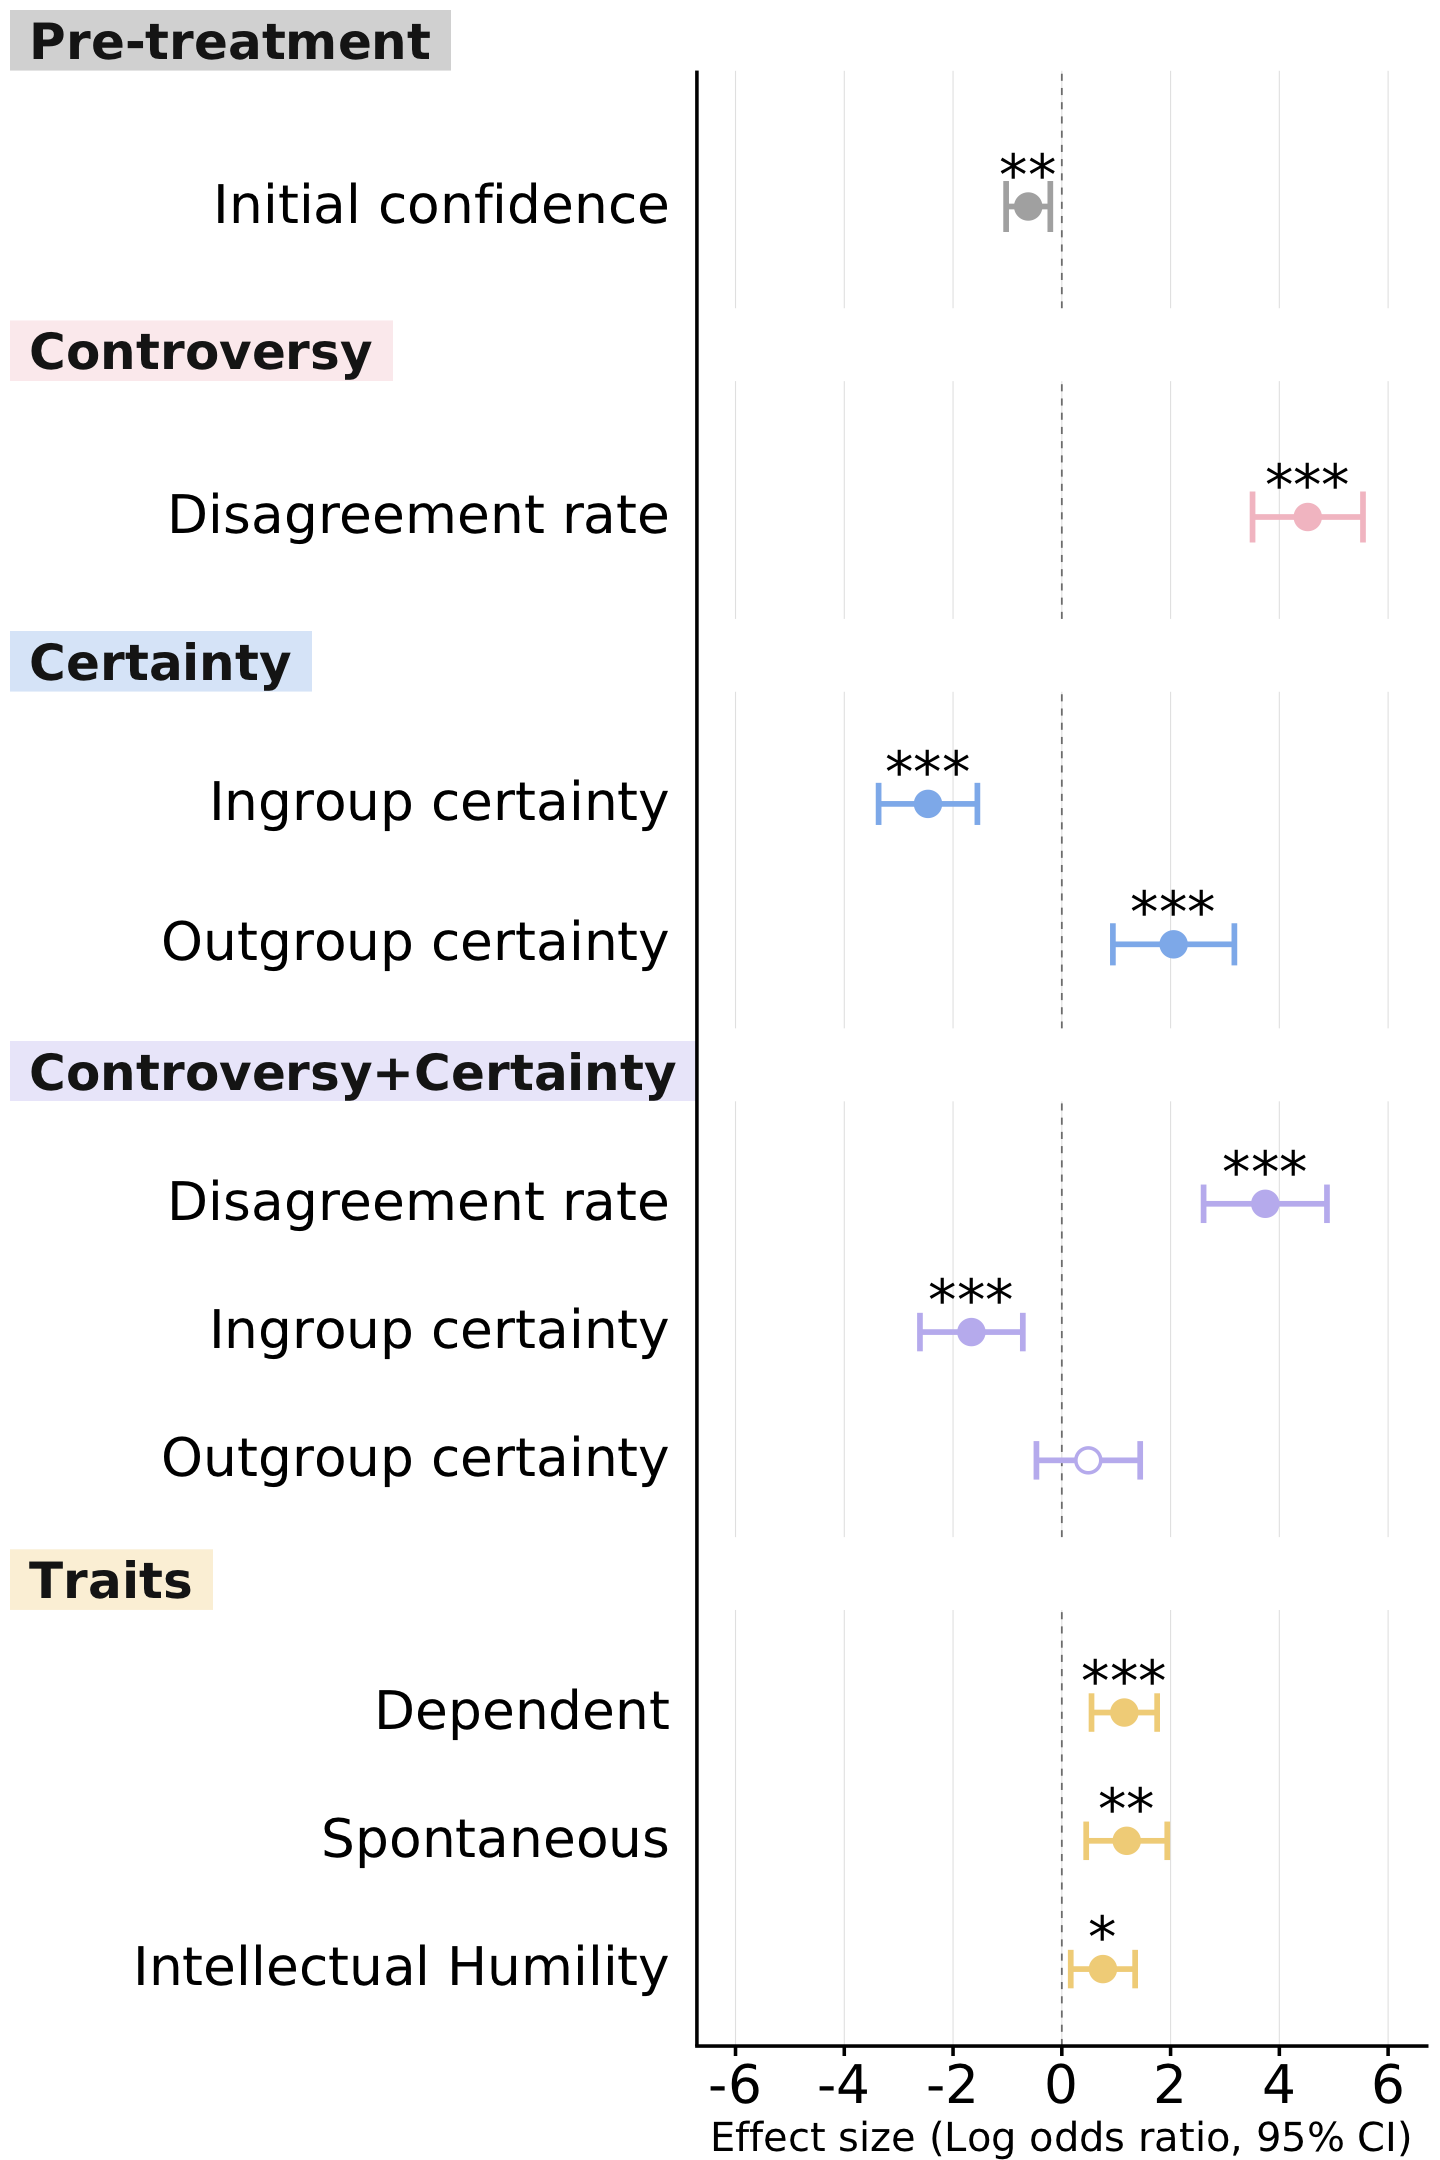

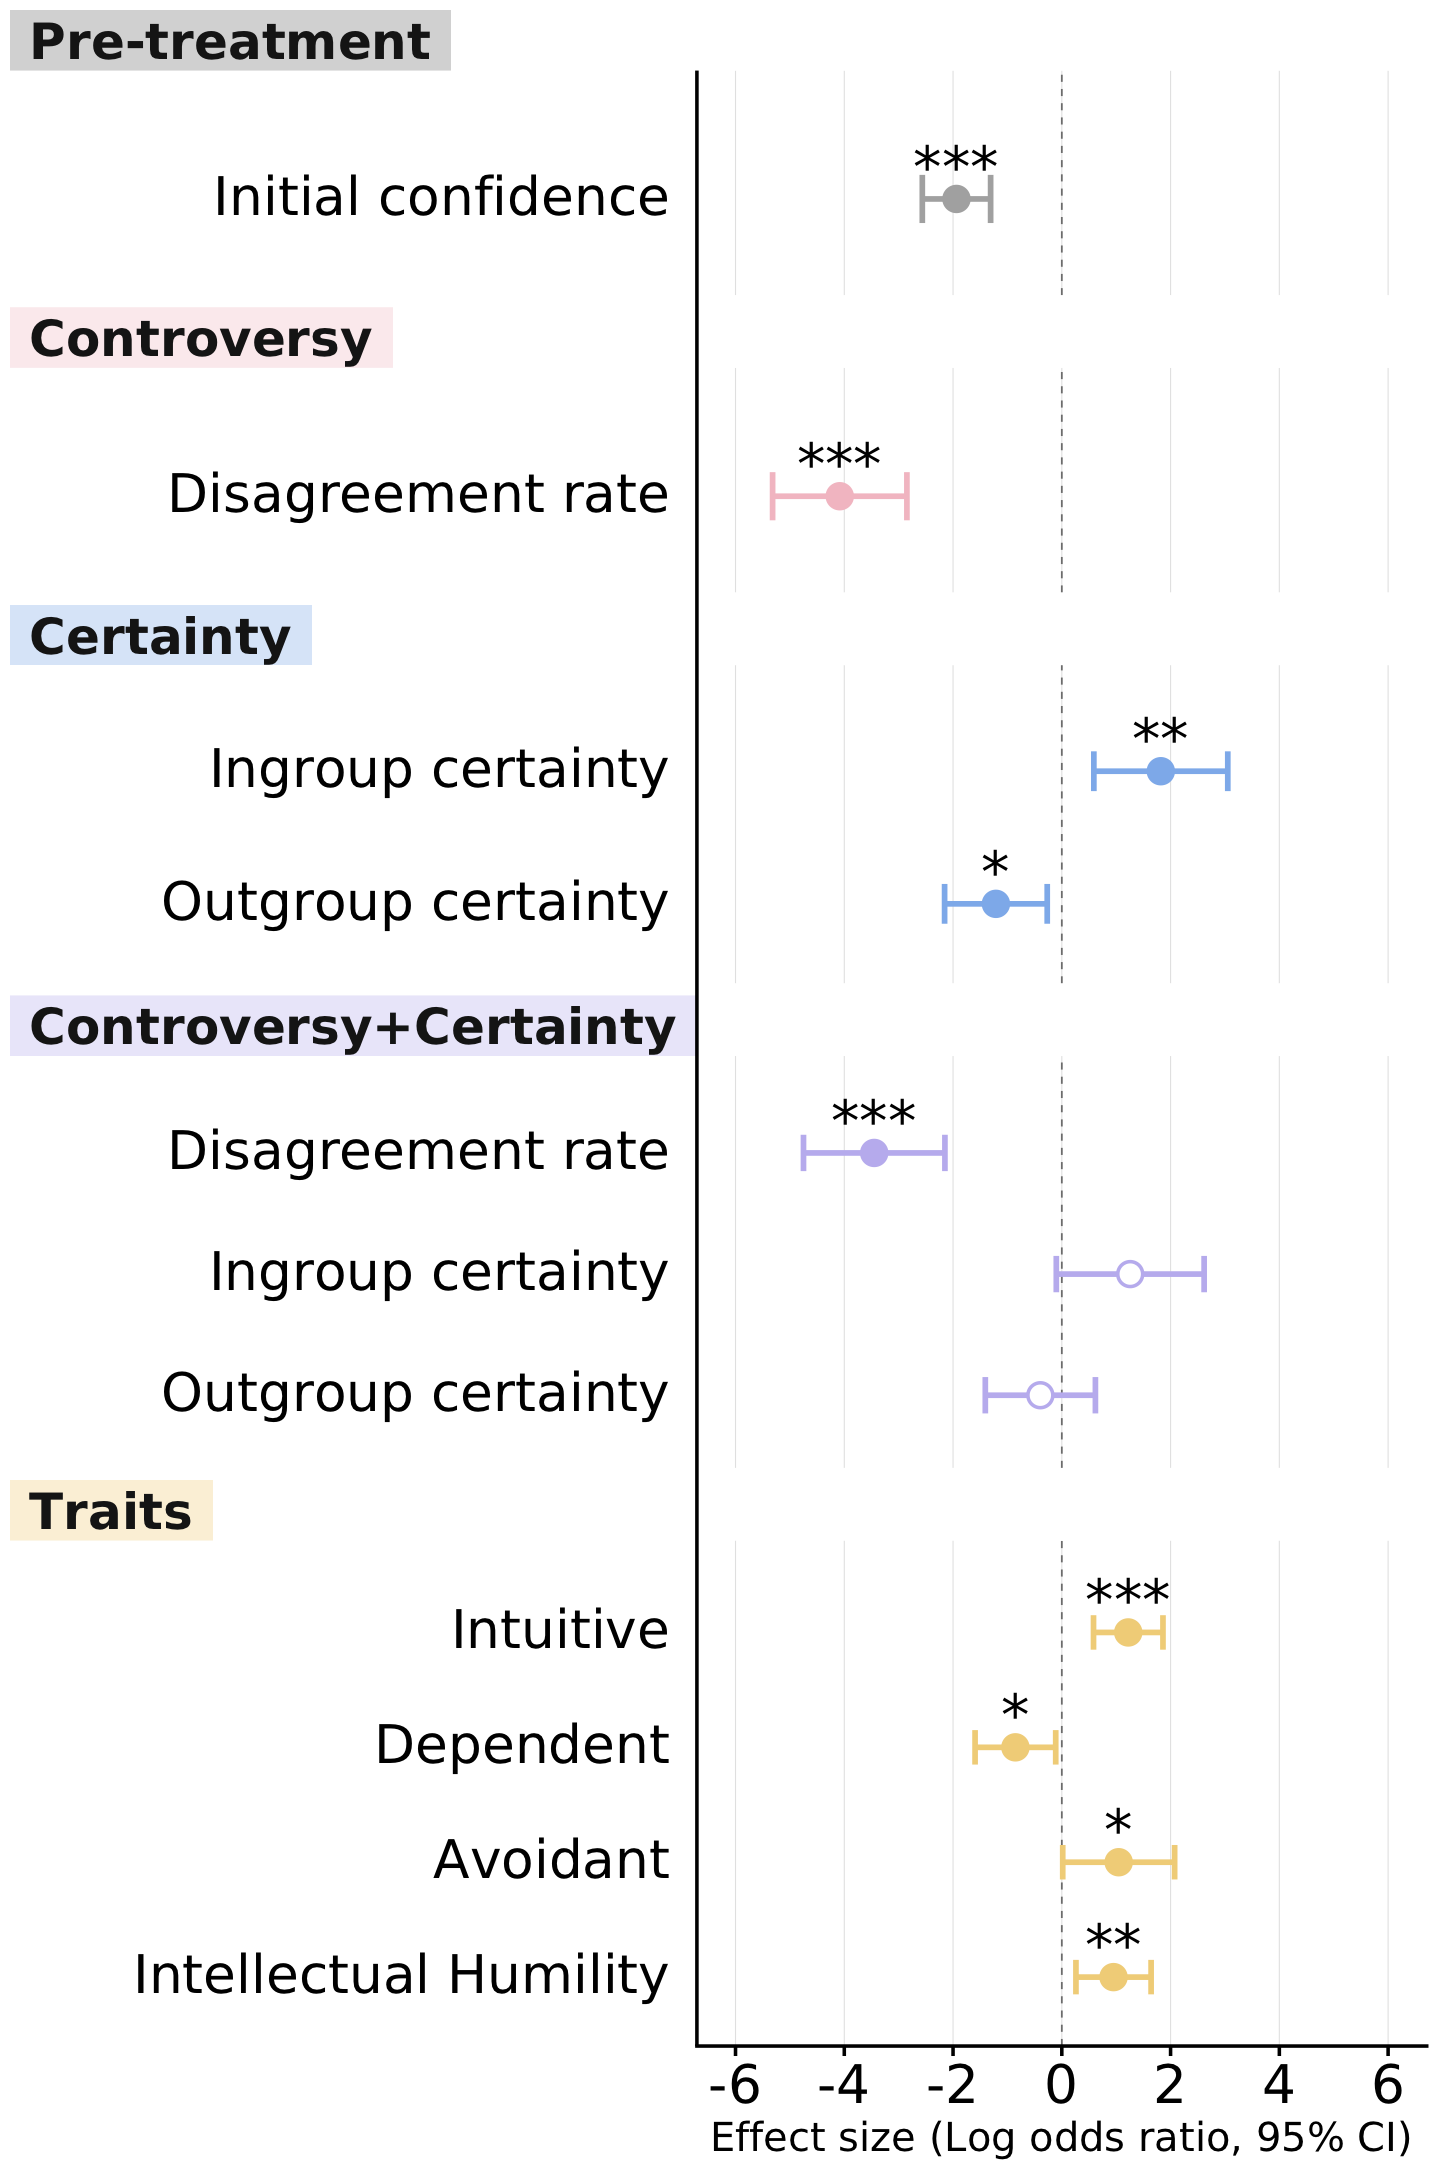

In [15]:
library(dplyr)
library(ggplot2)
library(ggh4x)

# ============================================================================
# Figures 3a (Weakening) and 3d (Strengthening) — coefficient forests
#
# Fits the two pinned formulas and plots their coefficients. Nothing here may
# reference a predictor that is not in one of those formulas; the guards below
# enforce that rather than trusting it.
#
# Demographics (Sex_grouped, Nationality_A) are adjustment covariates with no
# facet of their own; they are dropped explicitly via exclude_patterns rather
# than being allowed to fall through the unmatched-term path.
# ============================================================================

# ============================================================================
# 1) Interaction-name pattern helper
#    An interaction written `arm:(a + b)` is named by R as either `arm:a` or
#    `a:arm`, depending on the order terms enter the model frame. Matching only
#    one ordering silently drops the coefficient, so every pattern built here
#    accepts both.
# ============================================================================

ix <- function(arm, vars) {
  v <- paste(vars, collapse = "|")
  sprintf("^(%s:(%s)|(%s):%s)$", arm, v, v, arm)
}

PAT_CONTROVERSY <- ix("controversy", "disagree")
PAT_CERTAINTY   <- ix("certainty",   c("inconf", "outconf"))
PAT_BOTH        <- ix("both",        c("disagree", "inconf", "outconf"))

# ============================================================================
# 2) Coefficient extractor
# ============================================================================

extract_coef_df <- function(fit, treatment_map, exclude_patterns = NULL,
                            always_show_patterns = NULL,
                            clean_term, alpha = 0.05) {

  s       <- summary(fit)
  coef_df <- as.data.frame(s$coefficients)
  coef_df$term <- rownames(coef_df)
  colnames(coef_df) <- c("estimate", "se", "z_value", "p_value", "term")

  # Drop all intercept rows so they never reach the plot:
  #   global (Intercept) = control-arm baseline, plus the arm intercepts
  #   controversy / certainty / both.
  intercept_terms <- c("\\(Intercept\\)", "^controversy$", "^certainty$", "^both$")
  coef_df <- coef_df[!Reduce(`|`, lapply(intercept_terms,
                                         function(p) grepl(p, coef_df$term))), ]

  if (!is.null(exclude_patterns)) {
    mask <- Reduce(`|`, lapply(exclude_patterns,
                               function(pat) grepl(pat, coef_df$term)))
    coef_df <- coef_df[!mask, ]
  }

  coef_df$ci_lower    <- coef_df$estimate - 1.96 * coef_df$se
  coef_df$ci_upper    <- coef_df$estimate + 1.96 * coef_df$se
  coef_df$significant <- (coef_df$ci_lower > 0 | coef_df$ci_upper < 0)

  # Keep significant rows + any rows matching always_show_patterns.
  # always_show_patterns are kept even when non-significant so the reader
  # can see "this effect is null in this arm" for the in/out pair.
  keep_mask <- coef_df$significant
  if (!is.null(always_show_patterns)) {
    keep_always <- Reduce(`|`, lapply(always_show_patterns,
                                      function(pat) grepl(pat, coef_df$term)))
    keep_mask <- keep_mask | keep_always
  }
  coef_df <- coef_df[keep_mask, ]

  cat("Rows kept (significant + always_show):\n"); print(coef_df$term)

  coef_df$treatment <- NA_character_
  for (group_label in names(treatment_map)) {
    pat   <- treatment_map[[group_label]]
    match <- grepl(pat, coef_df$term)
    coef_df$treatment[match & is.na(coef_df$treatment)] <- group_label
  }

  # Anything unmatched at this point is a mapping bug, not a deliberate
  # omission -- deliberate omissions are listed in exclude_patterns above.
  # Silently dropping here is how the whole "Controversy + Certainty" facet
  # once went missing from both panels, so fail loudly instead.
  unmatched <- coef_df$term[is.na(coef_df$treatment)]
  if (length(unmatched) > 0) {
    stop("Terms matched no treatment group: ", paste(unmatched, collapse = ", "),
         "\n  Fix treatment_map, or add them to exclude_patterns if they are ",
         "adjustment covariates that should not be plotted.")
  }

  coef_df$predictor <- vapply(coef_df$term, clean_term, character(1))

  cat("\nFinal term -> predictor mapping:\n")
  print(coef_df[, c("term", "predictor", "treatment", "significant")])

  coef_df[, c("treatment", "predictor", "estimate", "se",
              "ci_lower", "ci_upper", "significant", "term")]
}

# ============================================================================
# 3) Term-name cleaner
#    Covers exactly the terms the two current formulas can produce. A term with
#    no entry raises an error rather than reaching the plot with a raw name --
#    that is the tripwire for a formula change made upstream without updating
#    this cell.
# ============================================================================

clean_term <- function(term) {
  arms <- c("controversy", "certainty", "both")
  # Normalise `var:arm` to `arm:var` so one table covers both orderings.
  parts <- strsplit(term, ":", fixed = TRUE)[[1]]
  if (length(parts) == 2 && parts[2] %in% arms) {
    term <- paste(parts[2], parts[1], sep = ":")
  }

  labels <- c(
    "c"                    = "Initial confidence",

    "controversy:disagree" = "Disagreement rate",
    "certainty:inconf"     = "Ingroup certainty",
    "certainty:outconf"    = "Outgroup certainty",
    "both:disagree"        = "Disagreement rate",
    "both:inconf"          = "Ingroup certainty",
    "both:outconf"         = "Outgroup certainty",

    "Intuitive"            = "Intuitive",
    "Dependent"            = "Dependent",
    "Rational"             = "Rational",
    "Avoidant"             = "Avoidant",
    "Spontaneous"          = "Spontaneous",
    "IH"                   = "Intellectual Humility"
  )

  if (!term %in% names(labels)) {
    stop("clean_term(): no label for '", term,
         "'. Add it here, or exclude the term from the plot.")
  }
  unname(labels[[term]])
}

# ============================================================================
# 4) Significance stars
# ============================================================================

get_stars <- function(estimate, se) {
  z <- abs(estimate / se)
  p <- 2 * (1 - pnorm(z))
  if (p < 0.001) return("***")
  if (p < 0.01)  return("**")
  if (p < 0.05)  return("*")
  if (p < 0.1)   return(".")
  return("")
}

# ============================================================================
# 5) Treatment-arm colors (used as fill and outline)
# ============================================================================

treat_colors <- c(
  "Pre-treatment"           = "#B0B0B0",
  "Controversy"             = "#F4C3CB",
  "Certainty"               = "#8FB8ED",
  "Controversy+Certainty" = "#C2BBF0",
  "Traits"                  = "#F2D388"
)

# fig3_bar_quadrant.ipynb tints its corner labels by drawing the arm color at
# alpha 0.3 over white. These fills are opaque, so blend 70% toward white to
# land on the same shade. Points and intervals keep the full-strength color.
# Width of every axis rule, including the continuous y rule drawn in
# strips_over_labels(). ggplot linewidth is mm; grid lwd is 1/96in, hence .pt.
AXIS_LW <- 1

# Vertical padding inside each panel, in row units -- the main lever on how
# tightly the predictors stack (0.8 left a lot of air). Asymmetric on purpose:
# the significance stars are drawn above their point, so the top row needs
# headroom or geom_text gets clipped at the panel edge.
Y_EXPAND     <- 0.6
Y_EXPAND_TOP <- 0.8

# Band fills are normally a 70%-to-white tint of the arm color, but
# Pre-treatment has to line up with fig3_bar_quadrant.ipynb, whose
# "Controversy OFF" / "Certainty OFF" corner labels draw matplotlib's 'gray'
# (#808080) at alpha 0.3 over white. That lands on #D9D9D9, whereas tinting
# this file's #B0B0B0 gives the lighter #E7E7E7. Pin it instead of tinting.
BAND_FILL_PINNED <- c("Pre-treatment" = "#D9D9D9")

lighten <- function(hex, toward_white = 0.7) {
  m <- grDevices::col2rgb(hex)
  grDevices::rgb(t(255 - (255 - m) * (1 - toward_white)), maxColorValue = 255)
}

# ============================================================================
# 6) Plot builder
#    Treatment arm as a colored title band sitting in the SAME column as the
#    predictor names, directly above its own group (see strips_over_labels()).
# ============================================================================

plot_coef_forest <- function(coef_df, conf_levels, predictor_order,
                             x_limits, x_breaks,
                             x_label = "Effect size (Log odds ratio, 95% CI)",
                             title   = NULL) {

  conf_levels <- intersect(conf_levels, unique(coef_df$treatment))

  # Every predictor present must have a slot in predictor_order, otherwise
  # factor() turns it into NA and the row vanishes from the panel.
  missing_lvl <- setdiff(unique(coef_df$predictor), predictor_order)
  if (length(missing_lvl) > 0) {
    stop("predictor_order is missing: ",
         paste(gsub("\n", " ", missing_lvl), collapse = ", "))
  }

  coef_df <- coef_df %>%
    mutate(
      treatment     = factor(treatment, levels = conf_levels),
      predictor     = factor(predictor, levels = predictor_order),
      stars         = mapply(function(est, se, sig) {
                              if (!sig) return("")
                              get_stars(est, se)
                            }, estimate, se, significant),
      treat_cols    = treat_colors[as.character(treatment)],
      interval_col  = treat_cols,
      point_fill    = ifelse(significant, treat_cols, "white"),
      point_outline = treat_cols
    )

  treat_sig <- coef_df %>%
    group_by(treatment) %>%
    summarise(any_sig = any(significant), .groups = "drop") %>%
    mutate(strip_fill = ifelse(any_sig,
                               lighten(treat_colors[as.character(treatment)]),
                               "gray95"),
           pinned     = BAND_FILL_PINNED[as.character(treatment)],
           strip_fill = ifelse(any_sig & !is.na(pinned), pinned, strip_fill))

  strip_bg_list <- lapply(
    setNames(treat_sig$strip_fill, treat_sig$treatment),
    function(cl) element_rect(fill = cl, color = NA)
  )

  # facet_wrap() has no `space = "free"`, so panel heights are set from each
  # arm's predictor count -- otherwise a 1-predictor arm gets as much vertical
  # room as a 3-predictor one. Include the expansion in the ratio: a panel spans
  # n + 2*Y_EXPAND row units, so sizing by n alone would leave the single-row
  # arms stacked tighter than the three-row ones.
  rows_per_treat <- as.integer(table(coef_df$treatment)) + Y_EXPAND + Y_EXPAND_TOP

  ggplot(coef_df, aes(x = estimate, y = predictor)) +
    geom_vline(xintercept = 0, linetype = "dashed",
               color = "gray50", linewidth = 0.5) +
    geom_errorbar(aes(xmin = ci_lower, xmax = ci_upper, color = interval_col),
                  linewidth = 1.6, width = 0.3, orientation = "y") +
    geom_point(aes(fill = point_fill, color = point_outline),
               size = 6, shape = 21, stroke = 1.5, na.rm = TRUE) +
    geom_text(aes(label = stars), vjust = -0.3, size = 12, family = PLOT_FONT) +
    ggh4x::facet_wrap2(
      vars(treatment), ncol = 1, scales = "free_y",
      strip.position = "top",
      strip = strip_themed(background_x = strip_bg_list)
    ) +
    ggh4x::force_panelsizes(rows = rows_per_treat) +
    scale_fill_identity() +
    scale_color_identity() +
    scale_x_continuous(limits = x_limits, breaks = x_breaks) +
    scale_y_discrete(expand = expansion(add = c(Y_EXPAND, Y_EXPAND_TOP))) +
    labs(x = x_label, y = NULL, title = title) +
    theme_classic(base_size = 24, base_family = PLOT_FONT) +
    theme(
      plot.title         = element_text(face = "bold", size = 28, hjust = 0.5),
      panel.grid.major.x = element_line(color = "gray90", linewidth = 0.3),
      strip.placement    = "outside",
      strip.text         = element_text(face = "bold", size = 30),
      # the band is sized from grobWidth(text), so these left/right margins are
      # what give it its horizontal padding
      strip.text.x       = element_text(angle = 0, hjust = 0, size = 30,
                                        margin = margin(5, 12, 5, 12)),
      # predictors right-aligned toward the panel, normal weight
      # margin r = gap between the label and the y rule
      axis.text.y        = element_text(face = "plain", size = 32,
                                        angle = 0, hjust = 1, vjust = +0.4,
                                        margin = margin(r = 16)),
      axis.ticks.y       = element_blank(),
      axis.line          = element_line(colour = "black", linewidth = AXIS_LW),
      axis.ticks.x       = element_line(colour = "black", linewidth = AXIS_LW),
      # theme_classic draws the y rule inside each panel, so five facets give
      # five disconnected segments; strips_over_labels() replaces it with one.
      axis.line.y        = element_blank(),
      plot.margin        = margin(t = 6, r = 8, b = 6, l = 6),
      axis.text.x        = element_text(size = 32),
      panel.spacing.y    = unit(0.5, "lines")
    )
}

# ============================================================================
# 7) Save helper — PNG + PDF, no cairo dependency
# ============================================================================

# ggplot draws a top strip across the panel only. Moving the strip grobs into
# the axis-label column turns each one into a title band sitting directly above
# its own predictor names, in the same column, instead of a header across the
# chart. Layout surgery, so it is re-derived from grob names on every call
# rather than hard-coding row/column indices.
strips_over_labels <- function(p) {
  g        <- ggplot2::ggplotGrob(p)
  is_strip <- grepl("^strip-t", g$layout$name)
  axis_col <- min(g$layout$l[grepl("^axis-l", g$layout$name)])
  if (!any(is_strip) || !is.finite(axis_col)) {
    warning("strips_over_labels(): no strip/axis grobs found; layout unchanged")
    return(g)
  }
  # Confine the band to the y-label column, above the predictor names.
  g$layout$l[is_strip] <- axis_col
  g$layout$r[is_strip] <- axis_col

  # Each strip is a gTree holding a background rect stretched to fill its cell,
  # plus the label. Shrink that rect onto the text so the band is a tag hugging
  # the title rather than a bar spanning the column, and pin both to the column's
  # left edge -- the same edge axis.text.y (hjust = 0) uses, so the title sits
  # directly above its predictor names instead of across the column from them.
  # grobWidth() resolves on the drawing device, so it holds at any ggsave() size.
  strip_w <- NULL
  for (i in which(is_strip)) {
    tr   <- g$grobs[[i]]$grobs[[1]]
    kids <- tr$children
    r_nm <- names(kids)[vapply(kids, inherits, logical(1), "rect")]
    t_nm <- names(kids)[vapply(kids, inherits, logical(1), "titleGrob")]
    if (length(r_nm) != 1 || length(t_nm) != 1) {
      warning("strips_over_labels(): unexpected strip grob; band left full-width")
      next
    }
    w       <- grid::grobWidth(tr$children[[t_nm]])
    strip_w <- if (is.null(strip_w)) w else grid::unit.pmax(strip_w, w)

    tr$children[[r_nm]]$x     <- grid::unit(0, "npc")
    tr$children[[r_nm]]$hjust <- 0
    tr$children[[r_nm]]$just  <- "left"
    tr$children[[r_nm]]$width <- w
    g$grobs[[i]]$grobs[[1]] <- tr
  }

  # ggplot sized this column for the predictor names alone -- the strips only
  # moved in afterwards -- so a longer title (e.g. "Controversy+Certainty")
  # would be clipped at the column edge. Widen the column to the widest title.
  if (!is.null(strip_w)) {
    g$widths[axis_col] <- grid::unit.pmax(g$widths[axis_col], strip_w)
  }

  # One unbroken y rule down the left edge of every panel, replacing the
  # per-panel segments that axis.line.y would have drawn. Spanning from the
  # first panel row to the last also covers the strip and spacing rows between
  # them, so the line reads as a single axis.
  pan <- g$layout[grepl("^panel", g$layout$name), ]
  if (nrow(pan) > 0) {
    g <- gtable::gtable_add_grob(
      g,
      grid::segmentsGrob(x0 = 0, x1 = 0, y0 = 0, y1 = 1,
                         gp = grid::gpar(col = "black", lwd = AXIS_LW * .pt,
                                         lineend = "butt")),
      t = min(pan$t), b = max(pan$b), l = min(pan$l), r = min(pan$l),
      name = "y-axis-rule", clip = "off")
  }
  g
}

# R's quartz png device colour-manages what it writes: a #D9D9D9 fill lands in
# the file as #D0D0D0, and black text as #141414. That is why these figures did
# not match fig3_bar_quadrant.ipynb (matplotlib/Agg, which writes sRGB verbatim)
# even with identical hex codes. ragg writes sRGB verbatim too. cairo would also
# work but needs XQuartz, which is not installed.
PNG_DEVICE <- if (requireNamespace("ragg", quietly = TRUE)) {
  ragg::agg_png
} else {
  warning("ragg not installed: the quartz device will shift every colour, so ",
          "these PNGs will not match the fig3_bar_quadrant figures. ",
          'Fix with install.packages("ragg").')
  NULL
}

save_plot <- function(p, base_name, width = 9, height = 9) {
  ggsave(file.path(FIG_DIR, paste0(base_name, ".png")), strips_over_labels(p),
         width = width, height = height, dpi = 600, bg = "white",
         device = PNG_DEVICE)
}

# ============================================================================
# 8) Shared settings for the two panels
# ============================================================================

conf_levels_full <- c("Pre-treatment", "Controversy", "Certainty",
                      "Controversy+Certainty", "Traits")

# 3a and 3e are read side by side, so they share one x axis. Deriving it from
# the widest CI across both panels also guarantees no interval is clipped --
# scale_x_continuous() drops out-of-range rows without warning.
shared_x_axis <- function(..., floor_at = 6) {
  tabs <- list(...)
  m <- max(abs(c(sapply(tabs, function(d) min(d$ci_lower)),
                 sapply(tabs, function(d) max(d$ci_upper)))))
  m <- max(ceiling(m / 2) * 2, floor_at)     # round out to an even number
  list(limits = c(-m - 0.1, m + 0.1), breaks = seq(-m, m, 2))
}

predictor_order_full <- rev(c(
  "Initial confidence",
  "Disagreement rate",
  "Ingroup certainty",
  "Outgroup certainty",
  "Intuitive", "Dependent", "Rational", "Avoidant", "Spontaneous",
  "Intellectual Humility"
))

treatment_map_full <- list(
  "Pre-treatment"           = "^c$",
  "Controversy"             = PAT_CONTROVERSY,
  "Certainty"               = PAT_CERTAINTY,
  "Controversy+Certainty" = PAT_BOTH,
  "Traits"                  = "^(Intuitive|Dependent|Rational|Avoidant|Spontaneous|IH)$"
)

# Show the full certainty block in every arm that has one, significant or not,
# so a reader can see where the ingroup/outgroup contrast is null.
always_show_full <- c(PAT_CERTAINTY, PAT_BOTH)

# Adjustment covariates: estimated, not plotted.
exclude_demographics <- c("^Sex_grouped", "^Nationality_A",
                          "^Country_A", "^raw_(country|nationality)")

# ============================================================================
# FIGURE 3a — Weakening (destablized)
# ============================================================================

cat("\n========== Weakening (Figure 3a) ==========\n")

# Formula comes from the cross-validated selection above, not a pinned
# string: `weak_best_result` is whatever the "Best model selection" cell
# chose. The guard fails loudly if that stops being a plain glm.
stopifnot(
  "Figure 3a coefficient extraction is glm-specific; weak_winner_family changed to a non-glm family - generalize extract_coef_df before proceeding." =
    weak_winner_family == "glm"
)

weak_formula_str <- paste(
  gsub("\\s+", " ", weak_best_result$base_str), "+",
  paste(weak_best_result$fixed, collapse = " + ")
)
cat("Weakening best-model formula (", weak_winner_family, "):\n",
    weak_formula_str, "\n", sep = "")

fit_weak <- glm(as.formula(weak_formula_str), data = df, family = binomial())

coef_weak <- extract_coef_df(
  fit_weak,
  treatment_map        = treatment_map_full,
  exclude_patterns     = exclude_demographics,
  always_show_patterns = always_show_full,
  clean_term           = clean_term
)

# ============================================================================
# FIGURE 3e — Strengthening (reinforced)
# ============================================================================

cat("\n========== Strengthening (Figure 3d) ==========\n")

# Rebuilt here so this cell is self-contained; must match the definition the
# model selection used. `c` is POMP-rescaled to [0, 1] upstream, so `c < 1`
# is the ceiling exclusion, and `judgment_changed` is exactly `j != j_2`.
df_reinf <- df %>%
  filter(.data$c < 1) %>%
  mutate(reinforced = as.integer(
    (.data$c_2 > .data$c) & (.data$judgment_changed == FALSE)
  ))

stopifnot(
  "Figure 3d coefficient extraction is glm-specific; strong_winner_family changed to a non-glm family - generalize extract_coef_df before proceeding." =
    strong_winner_family == "glm"
)

strong_formula_str <- paste(
  gsub("\\s+", " ", strong_best_result$base_str), "+",
  paste(strong_best_result$fixed, collapse = " + ")
)
cat("Strengthening best-model formula (", strong_winner_family, "):\n",
    strong_formula_str, "\n", sep = "")

fit_strong <- glm(as.formula(strong_formula_str), data = df_reinf,
                  family = binomial())

coef_strong <- extract_coef_df(
  fit_strong,
  treatment_map        = treatment_map_full,
  exclude_patterns     = exclude_demographics,
  always_show_patterns = always_show_full,
  clean_term           = clean_term
)

# ============================================================================
# Render both panels on the shared axis
# ============================================================================

xs <- shared_x_axis(coef_weak, coef_strong)
cat("\nShared x axis for 3a / 3e: [",
    xs$limits[1], ", ", xs$limits[2], "]\n", sep = "")

p_weak <- plot_coef_forest(
  coef_weak, conf_levels_full,
  predictor_order = predictor_order_full,
  x_limits = xs$limits, x_breaks = xs$breaks,
  x_label  = "Effect size (Log odds ratio, 95% CI)"
)

p_strong <- plot_coef_forest(
  coef_strong, conf_levels_full,
  predictor_order = predictor_order_full,
  x_limits = xs$limits, x_breaks = xs$breaks,
  x_label  = "Effect size (Log odds ratio, 95% CI)"
)

# Horizontal strips on the left need a wider canvas: the strip column is as
# wide as "Controversy + Certainty", and at 11in the panel was squeezed to a
# fraction of the figure with the x axis unreadable.
options(repr.plot.width = 12, repr.plot.height = 18)
save_plot(p_weak,   "fig3a_forest_weakening",     width = 12, height = 18)
save_plot(p_strong, "fig3d_forest_strengthening", width = 12, height = 18)
# print() would show the untouched ggplot -- band across the chart -- which is
# not what save_plot() writes. Draw the same gtable the PNGs use.
grid::grid.newpage(); grid::grid.draw(strips_over_labels(p_weak))
grid::grid.newpage(); grid::grid.draw(strips_over_labels(p_strong))


### Weakening

#### Figure 3c

Loading required package: nlme


Attaching package: ‘nlme’


The following object is masked from ‘package:dplyr’:

    collapse


This is mgcv 1.9-4. For overview type '?mgcv'.



Cell sizes:  In<Out = 432  In≥Out = 652 


Warning message:
“Duplicated `override.aes` is ignored.”
Warning message:
“Duplicated `override.aes` is ignored.”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“font family 'DejaVu Sans' not found in PostScript font database”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“font family 'DejaVu Sans' not found in PostScript font database”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“font family 'DejaVu Sans' not found in PostScript font database”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“font family 'DejaVu Sans' not found in PostScript font database”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“font family 'DejaVu Sans' not found in PostScript font database”
Warning message in grid.Call(C_stringMetric, as.graphicsAnnot(x$label)):
“font family 'DejaVu Sans' not found in PostScript font database”
Warning message in grid.Call(C_stringMetric, as.grap

Saved:
    figures/fig3c_weakening_vs_disagreement.png 


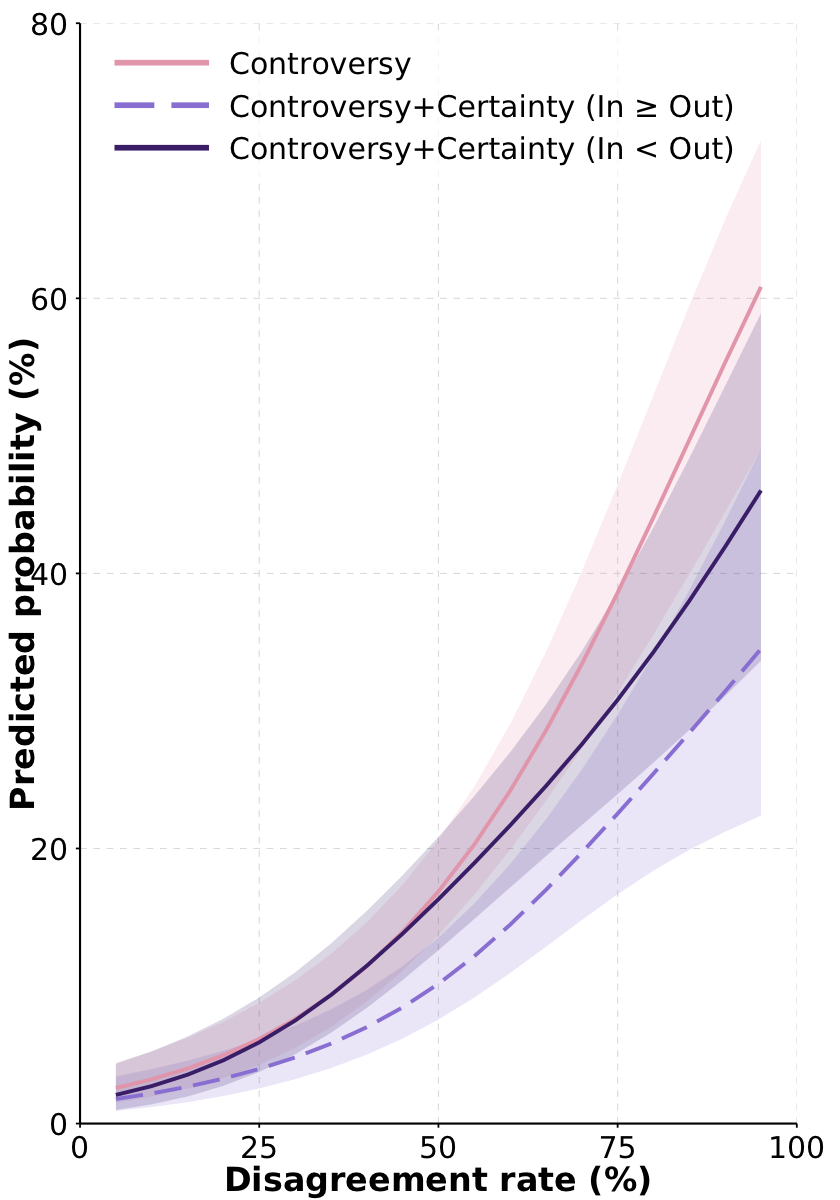

In [16]:
library(ggplot2)
library(dplyr)
library(mgcv)

# U+2265 built from its code point rather than typed literally: a literal
# would be read as three separate bytes under a non-UTF-8 locale (R's
# default is C unless the kernel sets otherwise), rendering as three
# fallback glyphs instead of one. intToUtf8 encodes correctly in any locale.
GE <- intToUtf8(0x2265)

# ============================================================
# Subsets
# ============================================================
cc_data <- subset(df, both == 1)               # C+C arm
cc_lt   <- subset(cc_data, inconf < outconf)  # In < Out (unfavorable)
cc_ge   <- subset(cc_data, inconf >= outconf)  # In ≥ Out (favorable)

cat("Cell sizes:  In<Out =", nrow(cc_lt),
    paste0(" In", GE, "Out ="), nrow(cc_ge), "\n")
# NOTE: if either cell is small, the gam below can wobble at the
# d extremes. Lower k, or switch to loess()/lm(), if so.

# ============================================================
# Baseline covariates (full-sample means / modes from df)
# ============================================================
baseline_cov <- list(
  c           = mean(df$c),
  Intuitive   = mean(df$Intuitive),
  Dependent   = mean(df$Dependent),
  Rational    = mean(df$Rational),
  Avoidant    = mean(df$Avoidant),
  Spontaneous = mean(df$Spontaneous)
)
if ("IH" %in% names(coef(fit_weak))) {
  baseline_cov$IH <- mean(df$IH)
}

get_mode <- function(x) {
  ux <- unique(x[!is.na(x)])
  ux[which.max(tabulate(match(x, ux)))]
}
model_vars <- all.vars(formula(fit_weak))
demo_ref <- list()
if ("Nationality_A" %in% model_vars) demo_ref$Nationality_A <- get_mode(df$Nationality_A)
if ("Sex_grouped"   %in% model_vars) demo_ref$Sex_grouped   <- get_mode(df$Sex_grouped)

build_newdata <- function(treatment, i_val = 0, o_val = 0, disagree_val = 0) {
  out <- data.frame(
    c           = baseline_cov$c,
    Intuitive   = baseline_cov$Intuitive,
    Dependent   = baseline_cov$Dependent,
    Rational    = baseline_cov$Rational,
    Avoidant    = baseline_cov$Avoidant,
    Spontaneous = baseline_cov$Spontaneous,
    controversy = ifelse(treatment == "controversy", 1, 0),
    certainty   = ifelse(treatment == "certainty",   1, 0),
    both        = ifelse(treatment == "both",        1, 0),
    disagree    = disagree_val,
    inconf      = i_val,
    outconf     = o_val
  )
  if (!is.null(baseline_cov$IH)) out$IH <- baseline_cov$IH
  if (!is.null(demo_ref$Nationality_A)) {
    out$Nationality_A <- factor(demo_ref$Nationality_A,
                                levels = levels(factor(df$Nationality_A)))
  }
  if (!is.null(demo_ref$Sex_grouped)) {
    out$Sex_grouped <- factor(demo_ref$Sex_grouped,
                              levels = levels(factor(df$Sex_grouped)))
  }
  out
}

predict_curve <- function(nd, xvals, label) {
  pr <- predict(fit_weak, newdata = nd, type = "link", se.fit = TRUE)
  data.frame(
    x     = xvals,
    p     = plogis(pr$fit),
    lo    = plogis(pr$fit - 1.96 * pr$se.fit),
    hi    = plogis(pr$fit + 1.96 * pr$se.fit),
    label = label,
    stringsAsFactors = FALSE
  )
}

# ============================================================
# Sweep grid, clipped to each subset's observed d range
# (no extrapolation past where a group actually has data)
# ============================================================
signal_range <- seq(0, 1, by = 0.05)

clip_range <- function(d) {
  rng <- range(d, na.rm = TRUE)
  signal_range[signal_range >= rng[1] & signal_range <= rng[2]]
}

x_ctrv <- clip_range(subset(df, controversy == 1)$disagree)
x_lt   <- clip_range(cc_lt$disagree)
x_ge   <- clip_range(cc_ge$disagree)

# ============================================================
# Within-subgroup empirical trajectories of i and o vs d
# (k modest to avoid overfitting in the smaller cell)
# ============================================================
fit_i_lt <- gam(inconf  ~ s(disagree, k = 5), data = cc_lt)
fit_o_lt <- gam(outconf ~ s(disagree, k = 5), data = cc_lt)
fit_i_ge <- gam(inconf  ~ s(disagree, k = 5), data = cc_ge)
fit_o_ge <- gam(outconf ~ s(disagree, k = 5), data = cc_ge)

# ============================================================
# Labels and colors
# ============================================================
lab_ctrv <- "Controversy"
lab_lt   <- "Controversy+Certainty (In < Out)"
lab_ge   <- paste0("Controversy+Certainty (In ", GE, " Out)")

col_ctrv  <- "#e8a8b8"   # Controversy (pink)
col_cc_lt <- "#4a2d7a"   # In < Out (dark purple, the key curve)
col_cc_ge <- "#9b86d9"   # In ≥ Out (light purple)

color_map   <- c(setNames(col_ctrv,  lab_ctrv),
                 setNames(col_cc_lt, lab_lt),
                 setNames(col_cc_ge, lab_ge))
level_order <- c(lab_ctrv,  lab_ge,lab_lt)

# linetype: reference and In < Out solid, In ≥ Out dashed
ltype_map   <- c(setNames("solid",    lab_ctrv),
                 setNames("solid",    lab_lt),
                 setNames("longdash", lab_ge))

# ============================================================
# Build curves
# ============================================================
curve_ctrv <- predict_curve(
  build_newdata("controversy", disagree_val = x_ctrv), x_ctrv, lab_ctrv)

nd_lt <- build_newdata("both", disagree_val = x_lt)
nd_lt$inconf  <- as.numeric(predict(fit_i_lt, newdata = data.frame(disagree = x_lt)))
nd_lt$outconf <- as.numeric(predict(fit_o_lt, newdata = data.frame(disagree = x_lt)))
curve_lt <- predict_curve(nd_lt, x_lt, lab_lt)

nd_ge <- build_newdata("both", disagree_val = x_ge)
nd_ge$inconf  <- as.numeric(predict(fit_i_ge, newdata = data.frame(disagree = x_ge)))
nd_ge$outconf <- as.numeric(predict(fit_o_ge, newdata = data.frame(disagree = x_ge)))
curve_ge <- predict_curve(nd_ge, x_ge, lab_ge)

curves_d <- rbind(curve_ctrv, curve_lt, curve_ge)
curves_d$label <- factor(curves_d$label, levels = level_order)

# ============================================================
# Theme (weakening style: bold large axis titles, large ticks,
# dashed major grid). Legend kept on: three curves need it.
# ============================================================
# Shared axis ranges for Figures 3c and 3f, so the two panels can be read
# against each other. The curves themselves still span only their own observed
# disagreement range (see clip_range above) -- this pins the axes, not the data.
Y_TOP <- 80
X_TOP <- 100

theme_curve <- theme_minimal(base_size = 10, base_family = PLOT_FONT) +
  theme(
    legend.position      = c(0.02, 0.86),
    legend.justification = c(0, 0),
    legend.text          = element_text(size = 18),
    legend.background    = element_rect(fill = scales::alpha("white", 0.7), color = NA),
    legend.key           = element_blank(),
    legend.key.width     = unit(2.5, "cm"),   # wide enough to show the dash
    legend.key.height    = unit(0.9, "cm"),
    legend.spacing.y     = unit(2, "pt"),
    axis.title.x         = element_text(face = "bold", size = 20),
    axis.title.y         = element_text(face = "bold", size = 20),
    axis.line            = element_line(color = "black", linewidth = 0.6),
    axis.ticks           = element_line(color = "black", linewidth = 0.5),
    axis.text            = element_text(color = "black", size = 18),
    panel.grid.major     = element_line(color = "gray88", linewidth = 0.3,
                                        linetype = "dashed"),
    panel.grid.minor     = element_blank(),
    # The top y label (80) is centred on the topmost tick, so half its height
    # sits above the panel. Without this margin ggsave clips it at the image
    # edge -- see Y_TOP below.
    # Outermost tick labels are centred on their tick, so half of each sits
    # outside the panel: 80 above the top, 100 to the right of the panel edge.
    # Without these margins ggsave trims them at the image boundary.
    plot.margin          = margin(t = 14, r = 26, b = 6, l = 6)
  )

p_d <- ggplot(curves_d, aes(x = x * 100)) +
  geom_ribbon(aes(ymin = lo * 100, ymax = hi * 100, fill = label),
              alpha = 0.18, color = NA) +
  geom_line(aes(y = p * 100, color = label, linetype = label), linewidth = 1.1) +
  scale_color_manual(values = color_map) +
  scale_fill_manual(values  = color_map, guide = "none") +
  scale_linetype_manual(values = ltype_map) +
  labs(x = "Disagreement rate (%)", y = "Predicted probability (%)",
       color = NULL, fill = NULL, linetype = NULL) +
  guides(
    color    = guide_legend(override.aes = list(linewidth = 1.6)),
    linetype = guide_legend(override.aes = list(linewidth = 1.6))
  ) +
  # Both panels are pinned to the same range so 3c and 3f can be read against
  # each other; 80 is the highest tick either one needs. coord_cartesian (not
  # scale limits) so a ribbon reaching past the top is clipped visually rather
  # than dropped, which would leave a gap in the band.
  scale_y_continuous(breaks = seq(0, Y_TOP, 20),
                     expand = expansion(mult = c(0, 0))) +
  scale_x_continuous(breaks = seq(0, X_TOP, 25),
                     expand = expansion(mult = c(0, 0))) +
  coord_cartesian(xlim = c(0, X_TOP), ylim = c(0, Y_TOP)) +
  theme_curve

ggsave(file.path(FIG_DIR, "fig3c_weakening_vs_disagreement.png"), p_d, width = 7, height = 10, dpi = 1000,
       device = PLOT_DEVICE)
options(repr.plot.width = 7, repr.plot.height =10)
print(p_d)
cat("Saved:\n",
    "  ", file.path(FIG_DIR, "fig3c_weakening_vs_disagreement.png"), "\n")

## Strengthening

#### Figure 3f

Cell sizes:  In<Out = 215  In≥Out = 298 


Warning message:
“Duplicated `override.aes` is ignored.”
Warning message:
“Duplicated `override.aes` is ignored.”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'DejaVu Sans' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'DejaVu Sans' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'DejaVu Sans' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'DejaVu Sans' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'DejaVu Sans' not found in PostScript font database”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font family 'DejaVu Sans' not found in PostScript font database

Saved:
    figures/fig3f_strengthening_vs_disagreement.png 


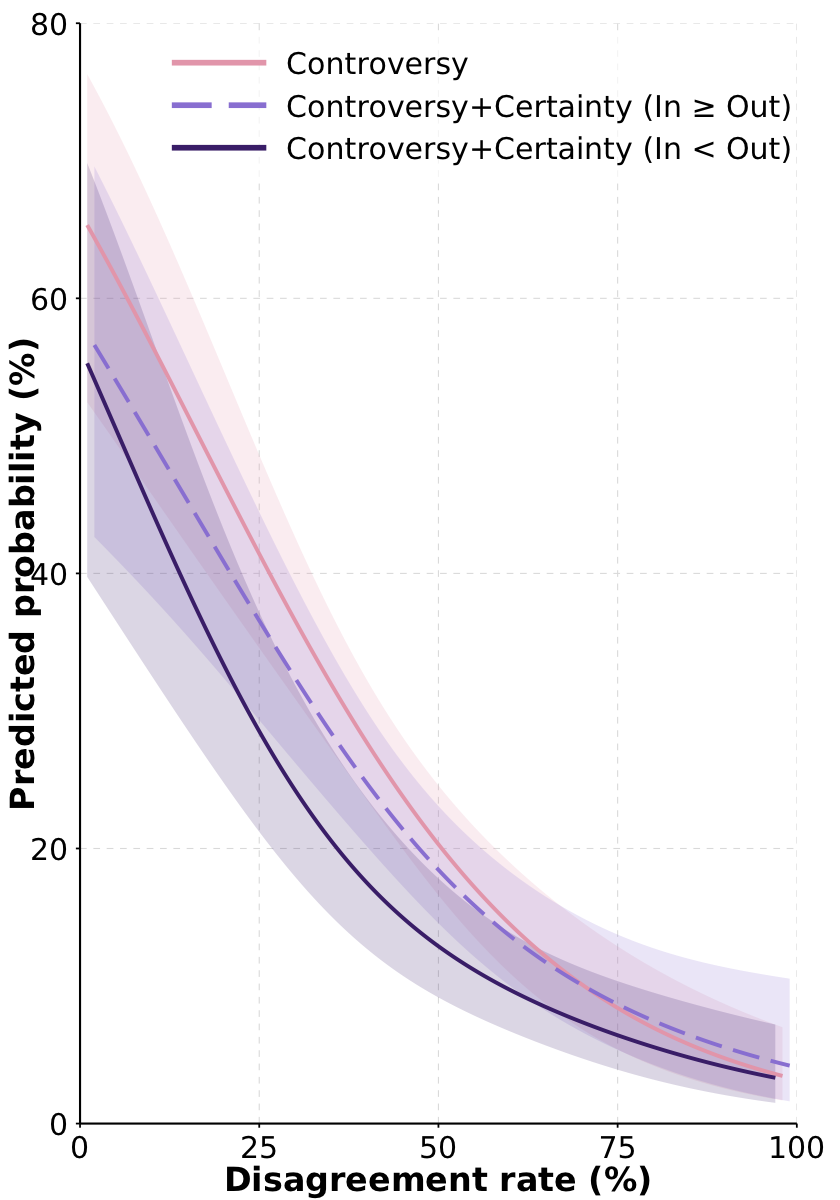

In [17]:
library(ggplot2)
library(dplyr)
library(mgcv)

# U+2265 built from its code point rather than typed literally: a literal
# would be read as three separate bytes under a non-UTF-8 locale (R's
# default is C unless the kernel sets otherwise), rendering as three
# fallback glyphs instead of one. intToUtf8 encodes correctly in any locale.
GE <- intToUtf8(0x2265)

# ============================================================
# Subsets
# ============================================================
cc_data <- subset(df_reinf, both == 1)         # C+C arm
cc_lt   <- subset(cc_data, inconf < outconf)  # In < Out (unfavorable)
cc_ge   <- subset(cc_data, inconf >= outconf)  # In ≥ Out (favorable)

cat("Cell sizes:  In<Out =", nrow(cc_lt),
    paste0(" In", GE, "Out ="), nrow(cc_ge), "\n")
# NOTE: if either cell is small, the gam below can wobble at the
# d extremes. Lower k, or switch to loess()/lm(), if so.

# ============================================================
# Baseline covariates (full-sample means / modes from df_reinf)
# ============================================================
baseline_cov <- list(
  c           = mean(df_reinf$c),
  Intuitive   = mean(df_reinf$Intuitive),
  Dependent   = mean(df_reinf$Dependent),
  Rational    = mean(df_reinf$Rational),
  Avoidant    = mean(df_reinf$Avoidant),
  Spontaneous = mean(df_reinf$Spontaneous)
)
if ("IH" %in% names(coef(fit_strong))) {
  baseline_cov$IH <- mean(df_reinf$IH)
}

get_mode <- function(x) {
  ux <- unique(x[!is.na(x)])
  ux[which.max(tabulate(match(x, ux)))]
}
model_vars <- all.vars(formula(fit_strong))
demo_ref <- list()
if ("Nationality_A" %in% model_vars) demo_ref$Nationality_A <- get_mode(df_reinf$Nationality_A)
if ("Sex_grouped"   %in% model_vars) demo_ref$Sex_grouped   <- get_mode(df_reinf$Sex_grouped)

build_newdata <- function(treatment, i_val = 0, o_val = 0, disagree_val = 0) {
  out <- data.frame(
    c           = baseline_cov$c,
    Intuitive   = baseline_cov$Intuitive,
    Dependent   = baseline_cov$Dependent,
    Rational    = baseline_cov$Rational,
    Avoidant    = baseline_cov$Avoidant,
    Spontaneous = baseline_cov$Spontaneous,
    controversy = ifelse(treatment == "controversy", 1, 0),
    certainty   = ifelse(treatment == "certainty",   1, 0),
    both        = ifelse(treatment == "both",        1, 0),
    disagree    = disagree_val,
    inconf      = i_val,
    outconf     = o_val
  )
  if (!is.null(baseline_cov$IH)) out$IH <- baseline_cov$IH
  if (!is.null(demo_ref$Nationality_A)) {
    out$Nationality_A <- factor(demo_ref$Nationality_A,
                                levels = levels(factor(df_reinf$Nationality_A)))
  }
  if (!is.null(demo_ref$Sex_grouped)) {
    out$Sex_grouped <- factor(demo_ref$Sex_grouped,
                              levels = levels(factor(df_reinf$Sex_grouped)))
  }
  out
}

predict_curve <- function(nd, xvals, label) {
  pr <- predict(fit_strong, newdata = nd, type = "link", se.fit = TRUE)
  data.frame(
    x     = xvals,
    p     = plogis(pr$fit),
    lo    = plogis(pr$fit - 1.96 * pr$se.fit),
    hi    = plogis(pr$fit + 1.96 * pr$se.fit),
    label = label,
    stringsAsFactors = FALSE
  )
}

# ============================================================
# Sweep grid, clipped to each subset's observed d range
# (no extrapolation past where a group actually has data)
# ============================================================
signal_range <- seq(0, 1, by = 0.005)

clip_range <- function(d) {
  rng <- range(d, na.rm = TRUE)
  signal_range[signal_range >= rng[1] & signal_range <= rng[2]]
}

x_ctrv <- clip_range(subset(df_reinf, controversy == 1)$disagree)
x_lt   <- clip_range(cc_lt$disagree)
x_ge   <- clip_range(cc_ge$disagree)

# ============================================================
# Within-subgroup empirical trajectories of i and o vs d
# (k modest to avoid overfitting in the smaller cell)
# ============================================================
fit_i_lt <- gam(inconf  ~ s(disagree, k = 5), data = cc_lt)
fit_o_lt <- gam(outconf ~ s(disagree, k = 5), data = cc_lt)
fit_i_ge <- gam(inconf  ~ s(disagree, k = 5), data = cc_ge)
fit_o_ge <- gam(outconf ~ s(disagree, k = 5), data = cc_ge)

# ============================================================
# Labels and colors
# ============================================================
lab_ctrv <- "Controversy"
lab_lt   <- "Controversy+Certainty (In < Out)"
lab_ge   <- paste0("Controversy+Certainty (In ", GE, " Out)")

col_ctrv  <- "#e8a8b8"   # Controversy (pink)
col_cc_lt <- "#4a2d7a"   # In < Out (dark purple, the key curve)
col_cc_ge <- "#9b86d9"   # In ≥ Out (light purple)

color_map   <- c(setNames(col_ctrv,  lab_ctrv),
                 setNames(col_cc_lt, lab_lt),
                 setNames(col_cc_ge, lab_ge))
level_order <- c(lab_ctrv, lab_ge, lab_lt)

# linetype: reference and In < Out solid, In ≥ Out dashed
ltype_map   <- c(setNames("solid",    lab_ctrv),
                 setNames("solid",    lab_lt),
                 setNames("longdash", lab_ge))

# ============================================================
# Build curves
# ============================================================
curve_ctrv <- predict_curve(
  build_newdata("controversy", disagree_val = x_ctrv), x_ctrv, lab_ctrv)

nd_lt <- build_newdata("both", disagree_val = x_lt)
nd_lt$inconf  <- as.numeric(predict(fit_i_lt, newdata = data.frame(disagree = x_lt)))
nd_lt$outconf <- as.numeric(predict(fit_o_lt, newdata = data.frame(disagree = x_lt)))
curve_lt <- predict_curve(nd_lt, x_lt, lab_lt)

nd_ge <- build_newdata("both", disagree_val = x_ge)
nd_ge$inconf  <- as.numeric(predict(fit_i_ge, newdata = data.frame(disagree = x_ge)))
nd_ge$outconf <- as.numeric(predict(fit_o_ge, newdata = data.frame(disagree = x_ge)))
curve_ge <- predict_curve(nd_ge, x_ge, lab_ge)

curves_d <- rbind(curve_ctrv, curve_lt, curve_ge)
curves_d$label <- factor(curves_d$label, levels = level_order)

# ============================================================
# Theme (weakening style: bold large axis titles, large ticks,
# dashed major grid). Legend kept on: three curves need it.
# Wide keys so the dashed line reads in the legend.
# ============================================================
# Shared axis ranges for Figures 3c and 3f, so the two panels can be read
# against each other. The curves themselves still span only their own observed
# disagreement range (see clip_range above) -- this pins the axes, not the data.
Y_TOP <- 80
X_TOP <- 100

theme_curve <- theme_minimal(base_size = 10, base_family = PLOT_FONT) +
  theme(
    legend.position      = c(0.1, 0.86),
    legend.justification = c(0, 0),
    legend.text          = element_text(size = 18),
    legend.background    = element_rect(fill = scales::alpha("white", 0.7), color = NA),
    legend.key           = element_blank(),
    legend.key.width     = unit(2.5, "cm"),
    legend.key.height    = unit(0.9, "cm"),
    legend.spacing.y     = unit(2, "pt"),
    axis.title.x         = element_text(face = "bold", size = 20),
    axis.title.y         = element_text(face = "bold", size = 20),
    axis.line            = element_line(color = "black", linewidth = 0.6),
    axis.ticks           = element_line(color = "black", linewidth = 0.5),
    axis.text            = element_text(color = "black", size = 18),
    panel.grid.major     = element_line(color = "gray88", linewidth = 0.3,
                                        linetype = "dashed"),
    panel.grid.minor     = element_blank(),
    # The top y label (80) is centred on the topmost tick, so half its height
    # sits above the panel. Without this margin ggsave clips it at the image
    # edge -- see Y_TOP below.
    # Outermost tick labels are centred on their tick, so half of each sits
    # outside the panel: 80 above the top, 100 to the right of the panel edge.
    # Without these margins ggsave trims them at the image boundary.
    plot.margin          = margin(t = 14, r = 26, b = 6, l = 6)
  )

p_d <- ggplot(curves_d, aes(x = x * 100)) +
  geom_ribbon(aes(ymin = lo * 100, ymax = hi * 100, fill = label),
              alpha = 0.18, color = NA) +
  geom_line(aes(y = p * 100, color = label, linetype = label), linewidth = 1.1) +
  scale_color_manual(values = color_map) +
  scale_fill_manual(values  = color_map, guide = "none") +
  scale_linetype_manual(values = ltype_map) +
  labs(x = "Disagreement rate (%)", y = "Predicted probability (%)",
       color = NULL, fill = NULL, linetype = NULL) +
  guides(
    color    = guide_legend(override.aes = list(linewidth = 1.6)),
    linetype = guide_legend(override.aes = list(linewidth = 1.6))
  ) +
  # Both panels are pinned to the same range so 3c and 3f can be read against
  # each other; 80 is the highest tick either one needs. coord_cartesian (not
  # scale limits) so a ribbon reaching past the top is clipped visually rather
  # than dropped, which would leave a gap in the band.
  scale_y_continuous(breaks = seq(0, Y_TOP, 20),
                     expand = expansion(mult = c(0, 0))) +
  scale_x_continuous(breaks = seq(0, X_TOP, 25),
                     expand = expansion(mult = c(0, 0))) +
  coord_cartesian(xlim = c(0, X_TOP), ylim = c(0, Y_TOP)) +
  theme_curve

ggsave(file.path(FIG_DIR, "fig3f_strengthening_vs_disagreement.png"), p_d, width = 7, height = 10, dpi = 1000,
       device = PLOT_DEVICE)
options(repr.plot.width = 7, repr.plot.height = 10)
print(p_d)
cat("Saved:\n",
    "  ", file.path(FIG_DIR, "fig3f_strengthening_vs_disagreement.png"), "\n")